# 🛡️ Robust Reward Design for MDPs in Cybersecurity
## Full Experiment Suite — Journal Production Notebook

> **Đề tài:** Robust Reward Design for MDPs in Cybersecurity: A Probabilistic Attack-Graph Case Study  
> **Mô hình:** Stackelberg Leader-Follower trên MDP / Attack Graph  
> **Solver:** PuLP + CBC (không cần Gurobi)

---
### Cấu trúc notebook này

| # | Phần | Nội dung |
|---|------|---------|
| 0 | Setup & Imports | Cài đặt môi trường, import, cấu hình global |
| 1 | Kiểm tra & Validate | Load và validate tất cả config |
| 2 | Trực quan hóa Attack Graphs | Vẽ sơ đồ tất cả kịch bản |
| 3 | Thực nghiệm cốt lõi: Standard vs Robust | Chạy MILP và IP solver cho 3 case |
| 4 | Phân tích Optimistic / Pessimistic Values | So sánh gap giữa hai phương án |
| 5 | Budget Sweep | Quét ngân sách C → tìm phase transition |
| 6 | Bounded-Rational Attacker (τ sweep) | Quét tham số lý trí giới hạn τ |
| 7 | Reward Perception Sensitivity (ε sweep) | Quét nhiễu nhận thức phần thưởng ε |
| 8 | Phân tích Intervention Sites | Đánh giá và xếp hạng các điểm can thiệp |
| 9 | Scalable Heuristics (Large Graphs) | Chạy pipeline heuristic cho đồ thị lớn |
| 10 | Bảng tổng hợp cho Paper | Xuất tất cả bảng số liệu chuẩn paper |
| 11 | Xuất kết quả | Lưu CSV, JSON, hình ảnh |

---

## 0. Setup & Imports

In [1]:
# ── 0.1 Cấu hình sys.path để import các module trong src/ ──────────────────
import sys
import os
from pathlib import Path

REPO_ROOT = Path(".").resolve()
SRC_DIR   = REPO_ROOT / "src"
CFG_DIR   = REPO_ROOT / "configs"
OUT_DIR   = REPO_ROOT / "results" / "notebook_run"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"✅ REPO_ROOT : {REPO_ROOT}")
print(f"✅ SRC_DIR   : {SRC_DIR}")
print(f"✅ CFG_DIR   : {CFG_DIR}")
print(f"✅ OUT_DIR   : {OUT_DIR}")

✅ REPO_ROOT : D:\robust_reward_design_journal_production_suite\robust_reward_design_lab
✅ SRC_DIR   : D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\src
✅ CFG_DIR   : D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\configs
✅ OUT_DIR   : D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run


In [2]:
# ── 0.2 Standard library imports ───────────────────────────────────────────
import json
import time
import math
import warnings
import random
from time import perf_counter
from copy import deepcopy
from dataclasses import asdict
from typing import Dict, List, Tuple, Any

warnings.filterwarnings("ignore")

# ── 0.3 Third-party imports ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx

# ── 0.4 Project imports ────────────────────────────────────────────────────
from mdp_model import AttackGraphMDP, load_mdp, InterventionSite
from standard_reward_design import solve_standard_reward_design, StandardResult
from robust_reward_design import solve_max_margin_reward_design, RobustResult
from evaluation import (
    optimistic_and_pessimistic_values,
    soft_response_summary,
    reward_perception_sweep,
    relaxed_pessimistic_value,
    soft_value_iteration,
    absorption_probabilities,
    discounted_defender_value_from_policy,
    ValueSummary, SoftResponseSummary, PerturbationSummary,
)
from visualization import build_networkx_graph, draw_attack_graph, plot_tau_sweep, plot_budget_sweep
from graph_generator import GeneratorConfig, generate_layered_attack_graph
from intervention_design import score_interventions, SiteScore
from scalable_heuristics import run_scalable_pipeline, topk_slack_allocation
from solver_utils import policy_from_occupancy, occupancy_from_policy

print(f"✅ Tất cả module đã được import thành công.")
print(f"   matplotlib : {matplotlib.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   pandas     : {pd.__version__}")
print(f"   networkx   : {nx.__version__}")

✅ Tất cả module đã được import thành công.
   matplotlib : 3.10.8
   numpy      : 2.0.1
   pandas     : 2.3.3
   networkx   : 3.3


In [3]:
# ── 0.5 Global matplotlib style ────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 130,
    "figure.facecolor"  : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 12,
    "legend.fontsize"   : 10,
    "lines.linewidth"   : 2.2,
    "lines.markersize"  : 8,
})

# Màu sắc nhất quán cho standard vs robust
COLOR_STANDARD = "#2C7BB6"  # xanh biển đậm
COLOR_ROBUST   = "#D7191C"  # đỏ đậm
COLOR_NEUTRAL  = "#4DAC26"  # xanh lá
CASE_COLORS    = ["#5E4FA2", "#3288BD", "#66C2A5"]

print("✅ Matplotlib style đã được cấu hình.")

✅ Matplotlib style đã được cấu hình.


In [4]:
# ── 0.6 Cấu hình thực nghiệm toàn cục (chỉnh ở đây để kiểm soát toàn bộ notebook) ─

# Danh sách các case config cần chạy thực nghiệm cốt lõi
CASE_CONFIGS = [
    str(CFG_DIR / "paper_style_attack_graph.json"),
    str(CFG_DIR / "branching_enterprise_graph.json"),
    str(CFG_DIR / "lateral_movement_graph.json"),
]

# Budget sweep: quét trên case paper_style
BUDGET_SWEEP_BASE_CASE = str(CFG_DIR / "paper_style_attack_graph.json")
BUDGET_GRID = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 3.0, 4.0, 5.0]

# τ sweep: quét bounded rationality
TAU_GRID = [2.0, 1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]

# ε sweep: reward perception perturbation
EPS_GRID = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
SAMPLES_PER_EPS = 30  # Số lần lấy mẫu ngẫu nhiên mỗi epsilon
PERTURB_SEED    = 42

# Thời gian tối đa cho mỗi lần giải MILP (giây)
TIME_LIMIT = 180

# Large graph cases
LARGE_CASE_CONFIGS = [
    str(CFG_DIR / "large_enterprise_64.json"),
    str(CFG_DIR / "large_enterprise_120.json"),
]

print("✅ Cấu hình thực nghiệm:")
print(f"   Cases chính     : {len(CASE_CONFIGS)} cases")
print(f"   Budget grid     : {BUDGET_GRID}")
print(f"   τ grid          : {TAU_GRID}")
print(f"   ε grid          : {EPS_GRID}")
print(f"   Samples/ε       : {SAMPLES_PER_EPS}")
print(f"   Time limit MILP : {TIME_LIMIT}s")

✅ Cấu hình thực nghiệm:
   Cases chính     : 3 cases
   Budget grid     : [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 3.0, 4.0, 5.0]
   τ grid          : [2.0, 1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]
   ε grid          : [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
   Samples/ε       : 30
   Time limit MILP : 180s


---
## 1. Load & Validate Tất Cả Config

In [5]:
# ── 1.1 Load và validate toàn bộ config ────────────────────────────────────
mdp_registry: Dict[str, AttackGraphMDP] = {}

print("Loading and validating MDPs...")
print("=" * 65)

for cfg_path in CASE_CONFIGS:
    try:
        mdp = load_mdp(cfg_path)
        mdp_registry[mdp.name] = mdp
        n_sa = len(mdp.sa_pairs)
        n_int = len(mdp.interventions)
        print(f"  ✅ [{mdp.name}]")
        print(f"     States: {len(mdp.states)} | SA-pairs: {n_sa} | Interventions: {n_int}")
        print(f"     Budget C = {mdp.budget} | Discount γ = {mdp.discount}")
        print(f"     True goals : {mdp.true_goals}")
        print(f"     Decoy sites: {mdp.decoy_sites}")
        print(f"     Sink state : {mdp.sink_state}")
        print()
    except Exception as e:
        print(f"  ❌ [{cfg_path}] FAILED: {e}")

print(f"Loaded {len(mdp_registry)}/{len(CASE_CONFIGS)} cases successfully.")

Loading and validating MDPs...
  ✅ [paper_style_attack_graph]
     States: 13 | SA-pairs: 40 | Interventions: 2
     Budget C = 2.4 | Discount γ = 0.95
     True goals : [9]
     Decoy sites: [10, 11]
     Sink state : 12

  ✅ [branching_enterprise_graph]
     States: 11 | SA-pairs: 32 | Interventions: 2
     Budget C = 2.0 | Discount γ = 0.95
     True goals : [7]
     Decoy sites: [8, 9]
     Sink state : 10

  ✅ [lateral_movement_graph]
     States: 10 | SA-pairs: 28 | Interventions: 2
     Budget C = 1.8 | Discount γ = 0.95
     True goals : [6]
     Decoy sites: [7, 8]
     Sink state : 9

Loaded 3/3 cases successfully.


In [6]:
# ── 1.2 In bảng đặc tính của từng MDP ─────────────────────────────────────
rows = []
for name, mdp in mdp_registry.items():
    total_transitions = sum(
        len(mdp.transitions[s][a])
        for s in mdp.states
        for a in mdp.available_actions[s]
    )
    rows.append({
        "Case"               : name,
        "|S|"                : len(mdp.states),
        "|A| max"            : max(len(v) for v in mdp.available_actions.values()),
        "|SA|"               : len(mdp.sa_pairs),
        "Interventions"      : len(mdp.interventions),
        "Budget C"           : mdp.budget,
        "Discount γ"         : mdp.discount,
        "True Goals"         : len(mdp.true_goals),
        "Decoy Sites"        : len(mdp.decoy_sites),
        "Total Transitions"  : total_transitions,
    })

df_meta = pd.DataFrame(rows)
print("📊 MDP Metadata Summary")
df_meta

📊 MDP Metadata Summary


,Case,|S|,|A| max,|SA|,Interventions,Budget C,Discount γ,True Goals,Decoy Sites,Total Transitions
0,paper_style_attack_graph,13,4,40,2,2.4,0.95,1,2,132
1,branching_enterprise_graph,11,4,32,2,2.0,0.95,1,2,88
2,lateral_movement_graph,10,4,28,2,1.8,0.95,1,2,76


In [7]:
# ── 1.3 In transition matrix của case paper_style (để debug / kiểm tra) ───
mdp_paper = mdp_registry["paper_style_attack_graph"]

print(f"📋 Transition probabilities — [{mdp_paper.name}]")
print(f"   (Hiển thị tất cả state-action-nextstate)")
print("=" * 60)

for s in mdp_paper.states:
    for a in mdp_paper.available_actions[s]:
        nxt = mdp_paper.transitions[s][a]
        nxt_str = ", ".join(f"{mdp_paper.label(ns)}: {p:.3f}" for ns, p in sorted(nxt.items()))
        r_att  = mdp_paper.attacker_reward.get((s, a), 0.0)
        r_def  = mdp_paper.defender_reward.get((s, a), 0.0)
        print(f"  s={mdp_paper.label(s):12s} a={a:5s} → [{nxt_str}]")
        if r_att != 0.0 or r_def != 0.0:
            print(f"           r_attacker={r_att:.2f}  r_defender={r_def:.2f}")

📋 Transition probabilities — [paper_style_attack_graph]
   (Hiển thị tất cả state-action-nextstate)
  s=start        a=a     → [recon_A: 0.700, recon_B: 0.100, recon_C: 0.100, recon_D: 0.100]
  s=start        a=b     → [recon_A: 0.100, recon_B: 0.700, recon_C: 0.100, recon_D: 0.100]
  s=start        a=c     → [recon_A: 0.100, recon_B: 0.100, recon_C: 0.700, recon_D: 0.100]
  s=start        a=d     → [recon_A: 0.100, recon_B: 0.100, recon_C: 0.100, recon_D: 0.700]
  s=recon_A      a=a     → [pivot_A: 0.700, pivot_B: 0.100, pivot_C: 0.100, pivot_D: 0.100]
  s=recon_A      a=b     → [pivot_A: 0.100, pivot_B: 0.700, pivot_C: 0.100, pivot_D: 0.100]
  s=recon_A      a=c     → [pivot_A: 0.100, pivot_B: 0.100, pivot_C: 0.700, pivot_D: 0.100]
  s=recon_A      a=d     → [pivot_A: 0.100, pivot_B: 0.100, pivot_C: 0.100, pivot_D: 0.700]
  s=recon_B      a=a     → [pivot_A: 0.200, pivot_B: 0.600, pivot_C: 0.100, pivot_D: 0.100]
  s=recon_B      a=b     → [pivot_A: 0.600, pivot_B: 0.200, pivot_C: 0.1

---
## 2. Trực Quan Hóa Attack Graphs

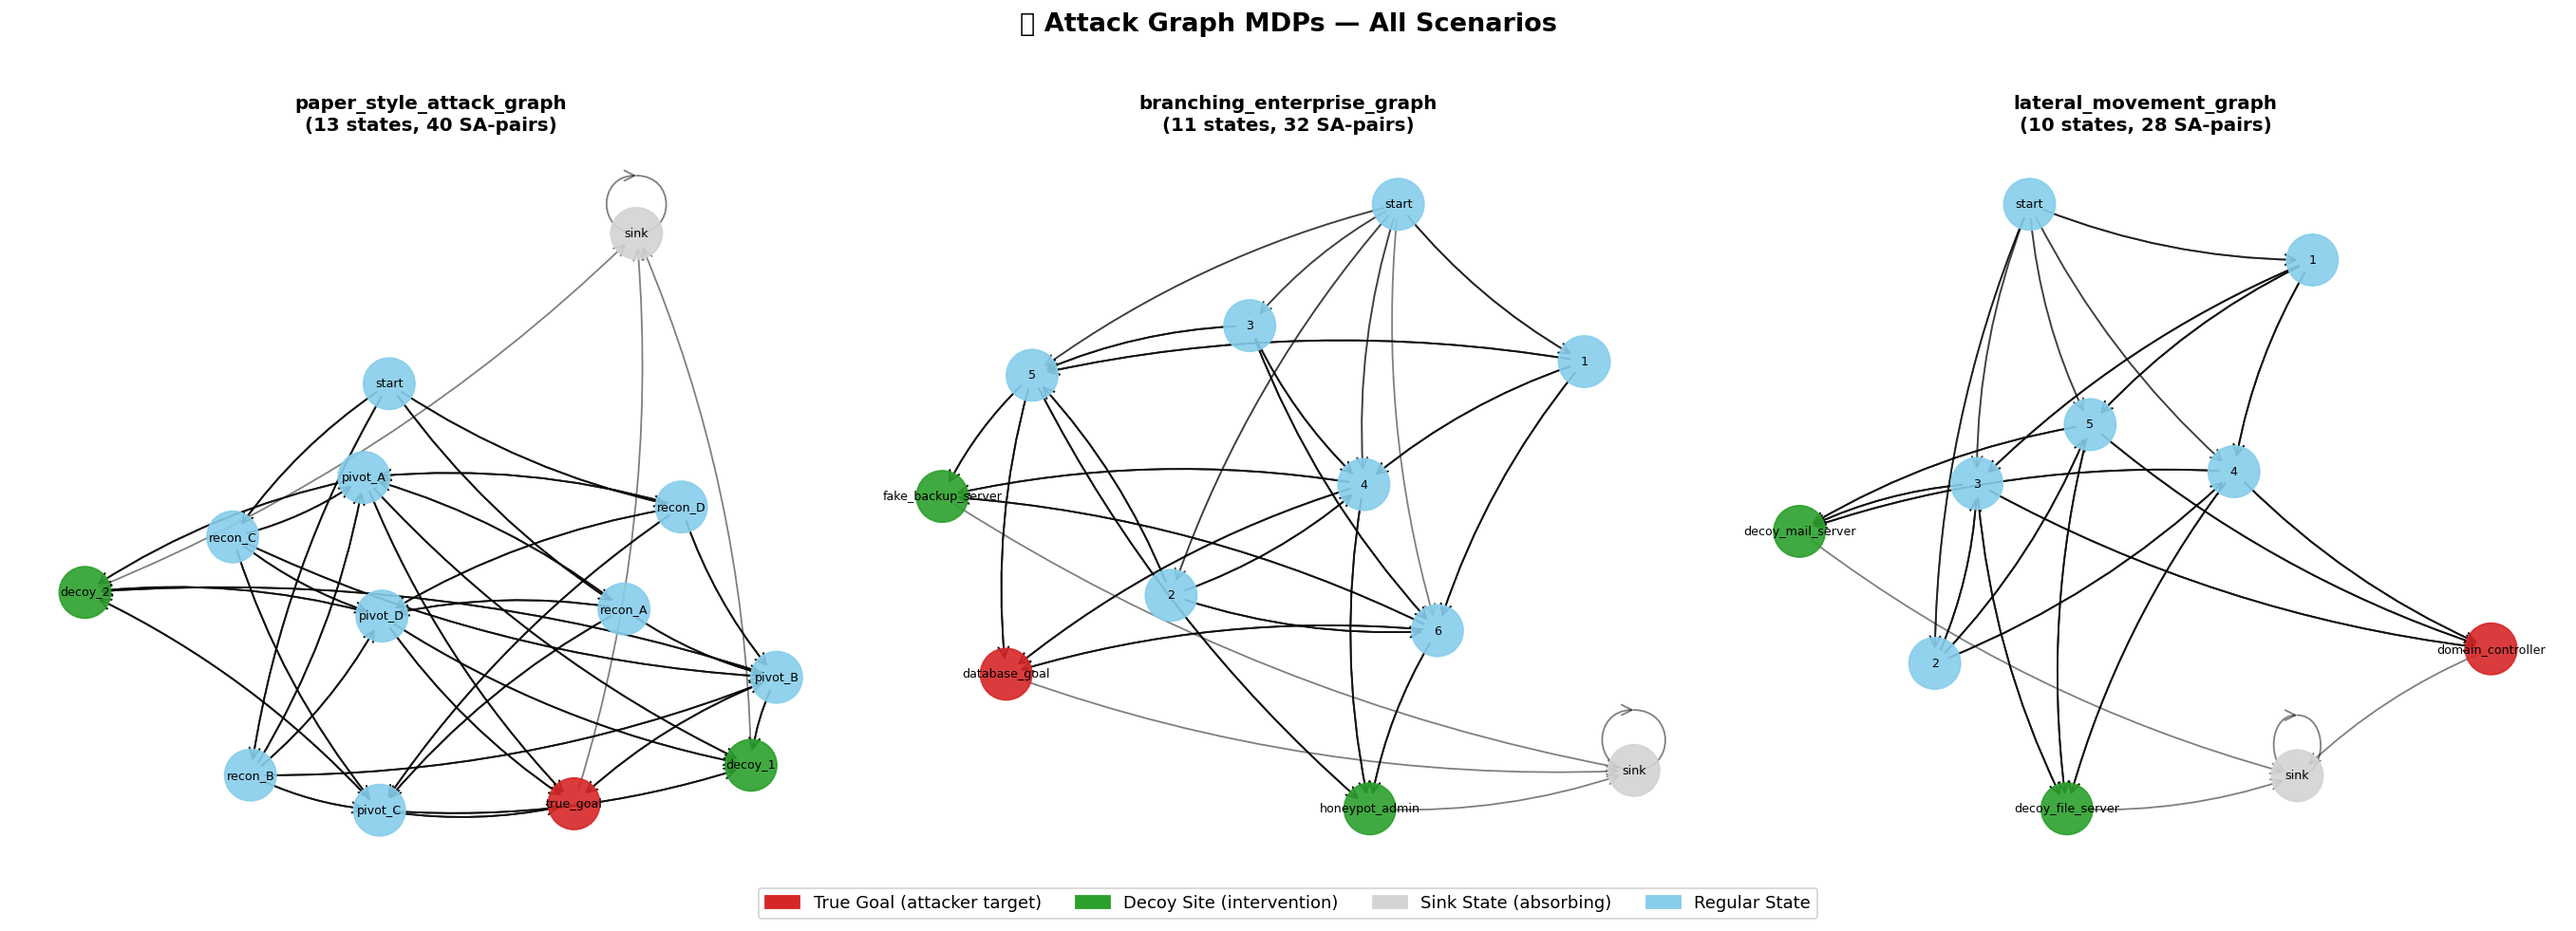

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\all_attack_graphs.png


In [8]:
# ── 2.1 Vẽ attack graph cho tất cả case trong một figure ─────────────────
fig, axes = plt.subplots(1, len(mdp_registry), figsize=(7 * len(mdp_registry), 7))
if len(mdp_registry) == 1:
    axes = [axes]

legend_patches = [
    mpatches.Patch(color="tab:red",   label="True Goal (attacker target)"),
    mpatches.Patch(color="tab:green", label="Decoy Site (intervention)"),
    mpatches.Patch(color="lightgray", label="Sink State (absorbing)"),
    mpatches.Patch(color="skyblue",   label="Regular State"),
]

for ax, (name, mdp) in zip(axes, mdp_registry.items()):
    G = build_networkx_graph(mdp)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=2.5)

    node_colors = []
    for n in G.nodes:
        if n in mdp.true_goals:
            node_colors.append("tab:red")
        elif n in mdp.decoy_sites:
            node_colors.append("tab:green")
        elif n == mdp.sink_state:
            node_colors.append("lightgray")
        else:
            node_colors.append("skyblue")

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=900, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={n: mdp.label(n) for n in G.nodes}, font_size=7)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, arrows=True,
                           arrowstyle="->", arrowsize=15,
                           connectionstyle="arc3,rad=0.1")
    ax.set_title(f"{name}\n({len(mdp.states)} states, {len(mdp.sa_pairs)} SA-pairs)", fontsize=11, fontweight="bold")
    ax.axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=10, frameon=True)
fig.suptitle("🗺️ Attack Graph MDPs — All Scenarios", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

fig_path = OUT_DIR / "all_attack_graphs.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

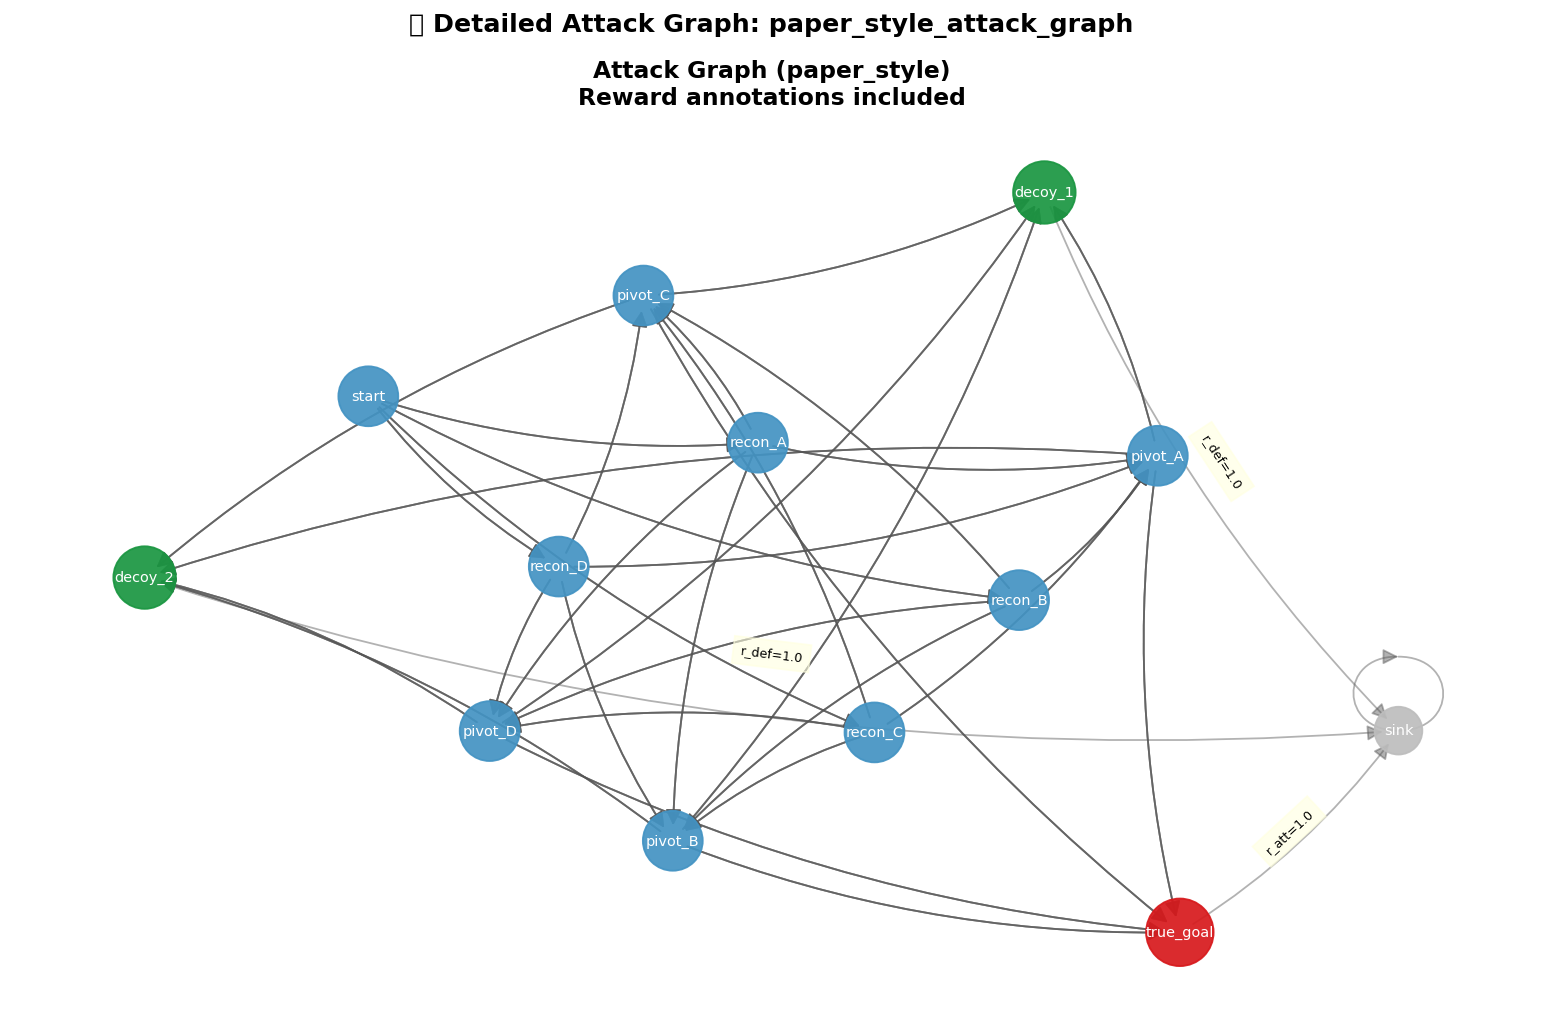

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\paper_style_detailed_graph.png


In [9]:
# ── 2.2 Vẽ chi tiết case paper_style với nhãn phần thưởng ─────────────────
def draw_graph_with_rewards(mdp: AttackGraphMDP, ax: plt.Axes, title: str) -> None:
    G = build_networkx_graph(mdp)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except Exception:
        pos = nx.spring_layout(G, seed=7, k=3.0)

    node_colors = []
    node_sizes  = []
    for n in G.nodes:
        if n in mdp.true_goals:
            node_colors.append("#D7191C")
            node_sizes.append(1400)
        elif n in mdp.decoy_sites:
            node_colors.append("#1A9641")
            node_sizes.append(1200)
        elif n == mdp.sink_state:
            node_colors.append("#BDBDBD")
            node_sizes.append(700)
        else:
            node_colors.append("#4393C3")
            node_sizes.append(1100)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.92)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={n: mdp.label(n) for n in G.nodes}, font_size=8, font_color="white")
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.45, arrows=True, arrowsize=18,
                           edge_color="#555", connectionstyle="arc3,rad=0.1")

    # Vẽ nhãn phần thưởng tại cạnh có phần thưởng khác 0
    reward_edge_labels = {}
    for (s, a), r in mdp.attacker_reward.items():
        if abs(r) > 1e-8:
            for ns in mdp.transitions[s][a]:
                reward_edge_labels[(s, ns)] = f"r_att={r:.1f}"
    for (s, a), r in mdp.defender_reward.items():
        if abs(r) > 1e-8:
            for ns in mdp.transitions[s][a]:
                k = (s, ns)
                old = reward_edge_labels.get(k, "")
                reward_edge_labels[k] = (old + f" r_def={r:.1f}").strip()

    nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=reward_edge_labels,
                                 font_size=7, bbox=dict(alpha=0.6, color="lightyellow", edgecolor="none"))

    ax.set_title(title, fontweight="bold")
    ax.axis("off")


fig, ax = plt.subplots(figsize=(12, 8))
draw_graph_with_rewards(mdp_paper, ax, f"Attack Graph (paper_style)\nReward annotations included")
fig.suptitle("📌 Detailed Attack Graph: paper_style_attack_graph", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = OUT_DIR / "paper_style_detailed_graph.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

---
## 3. Thực Nghiệm Cốt Lõi: Standard vs Robust Reward Design

Đây là thực nghiệm trung tâm của dự án. Với mỗi case:
- **Standard MILP** (`x_MILP`): Giải bài toán Stackelberg tiêu chuẩn → tối đa hóa defender value
- **Robust IP** (`x_IP`): Giữ nguyên $v_1^*$ nhưng tối đa hóa robust margin $c^*$

In [10]:
# ── 3.1 Chạy Standard + Robust cho tất cả cases ───────────────────────────
standard_results: Dict[str, StandardResult] = {}
robust_results:   Dict[str, RobustResult]   = {}

print("🚀 Bắt đầu giải MILP cho tất cả cases...")
print("=" * 65)

for name, mdp in mdp_registry.items():
    print(f"\n🔵 [{name}]")
    
    # --- Standard ---
    t0 = perf_counter()
    print(f"   Giải Standard MILP...", end=" ", flush=True)
    std = solve_standard_reward_design(mdp, solver_msg=False, time_limit_seconds=TIME_LIMIT)
    print(f"Done [{std.runtime_seconds:.2f}s] | status={std.solver_status} | v1*={std.v1_star:.6f}")
    standard_results[name] = std
    
    # --- Robust ---
    print(f"   Giải Robust MILP (max-margin)...", end=" ", flush=True)
    rob = solve_max_margin_reward_design(mdp, v1_star=std.v1_star, solver_msg=False, time_limit_seconds=TIME_LIMIT)
    print(f"Done [{rob.runtime_seconds:.2f}s] | status={rob.solver_status} | c*={rob.c_star:.6f}")
    robust_results[name] = rob
    
    # In phân bổ
    print(f"   Standard allocation x_MILP:")
    for (s, a), v in sorted(std.x_milp.items()):
        if abs(v) > 1e-6:
            print(f"     ({mdp.label(s)}, {a}) = {v:.6f}")
    print(f"   Robust allocation x_IP:")
    for (s, a), v in sorted(rob.x_ip.items()):
        if abs(v) > 1e-6:
            print(f"     ({mdp.label(s)}, {a}) = {v:.6f}")

print("\n" + "=" * 65)
print("✅ Tất cả cases đã được giải xong.")

🚀 Bắt đầu giải MILP cho tất cả cases...

🔵 [paper_style_attack_graph]
   Giải Standard MILP... Done [0.13s] | status=Optimal | v1*=0.676469
   Giải Robust MILP (max-margin)... Done [0.44s] | status=Optimal | c*=0.400000
   Standard allocation x_MILP:
     (decoy_1, end) = 1.000000
     (decoy_2, end) = 1.000000
   Robust allocation x_IP:
     (decoy_1, end) = 1.000000
     (decoy_2, end) = 1.400000

🔵 [branching_enterprise_graph]
   Giải Standard MILP... Done [0.04s] | status=Optimal | v1*=0.712975
   Giải Robust MILP (max-margin)... Done [0.09s] | status=Optimal | c*=0.000000
   Standard allocation x_MILP:
     (fake_backup_server, end) = 1.000000
     (honeypot_admin, end) = 1.000000
   Robust allocation x_IP:
     (fake_backup_server, end) = 1.000000
     (honeypot_admin, end) = 1.000000

🔵 [lateral_movement_graph]
   Giải Standard MILP... Done [0.04s] | status=Optimal | v1*=0.708508
   Giải Robust MILP (max-margin)... Done [0.13s] | status=Optimal | c*=0.400000
   Standard allocati

In [11]:
# ── 3.2 Tính Optimistic / Pessimistic values cho tất cả cases ─────────────
value_summaries_std: Dict[str, ValueSummary] = {}
value_summaries_rob: Dict[str, ValueSummary] = {}

print("📊 Tính Optimistic & Pessimistic values...")
for name, mdp in mdp_registry.items():
    vs_std = optimistic_and_pessimistic_values(mdp, standard_results[name].x_milp)
    vs_rob = optimistic_and_pessimistic_values(mdp, robust_results[name].x_ip)
    value_summaries_std[name] = vs_std
    value_summaries_rob[name] = vs_rob
    print(f"  [{name}]")
    print(f"    Standard — opt: {vs_std.defender_optimistic_value:.6f}  pes: {vs_std.defender_pessimistic_value:.6f}  gap: {vs_std.defender_optimistic_value - vs_std.defender_pessimistic_value:.6f}")
    print(f"    Robust   — opt: {vs_rob.defender_optimistic_value:.6f}  pes: {vs_rob.defender_pessimistic_value:.6f}  gap: {vs_rob.defender_optimistic_value - vs_rob.defender_pessimistic_value:.6f}")

print("✅ Xong.")

📊 Tính Optimistic & Pessimistic values...
  [paper_style_attack_graph]
    Standard — opt: 0.676469  pes: 0.329232  gap: 0.347237
    Robust   — opt: 0.676469  pes: 0.676468  gap: 0.000000
  [branching_enterprise_graph]
    Standard — opt: 0.712975  pes: 0.342950  gap: 0.370025
    Robust   — opt: 0.712975  pes: 0.342950  gap: 0.370025
  [lateral_movement_graph]
    Standard — opt: 0.708508  pes: 0.629086  gap: 0.079422
    Robust   — opt: 0.708508  pes: 0.708507  gap: 0.000000
✅ Xong.


---
## 4. Phân Tích Optimistic / Pessimistic Value Gap

In [12]:
# ── 4.1 Bảng so sánh đầy đủ Standard vs Robust ───────────────────────────
rows = []
for name in mdp_registry:
    std   = standard_results[name]
    rob   = robust_results[name]
    vs_s  = value_summaries_std[name]
    vs_r  = value_summaries_rob[name]
    rows.append({
        "Case"                     : name,
        "Budget C"                 : mdp_registry[name].budget,
        "v1* (Standard)"           : f"{std.v1_star:.5f}",
        "c* (Robust margin)"       : f"{rob.c_star:.5f}",
        "Std Opt Value"            : f"{vs_s.defender_optimistic_value:.5f}",
        "Std Pes Value"            : f"{vs_s.defender_pessimistic_value:.5f}",
        "Std Gap (Opt-Pes)"        : f"{vs_s.defender_optimistic_value - vs_s.defender_pessimistic_value:.5f}",
        "Rob Opt Value"            : f"{vs_r.defender_optimistic_value:.5f}",
        "Rob Pes Value"            : f"{vs_r.defender_pessimistic_value:.5f}",
        "Rob Gap (Opt-Pes)"        : f"{vs_r.defender_optimistic_value - vs_r.defender_pessimistic_value:.5f}",
        "Pes Improvement"          : f"{vs_r.defender_pessimistic_value - vs_s.defender_pessimistic_value:+.5f}",
        "Std Runtime (s)"          : f"{std.runtime_seconds:.2f}",
        "Rob Runtime (s)"          : f"{rob.runtime_seconds:.2f}",
    })

df_core = pd.DataFrame(rows)
print("📋 Table 1 — Core Experiment Results (Standard vs Robust)")
df_core

📋 Table 1 — Core Experiment Results (Standard vs Robust)


,Case,Budget C,v1* (Standard),c* (Robust margin),Std Opt Value,Std Pes Value,Std Gap (Opt-Pes),Rob Opt Value,Rob Pes Value,Rob Gap (Opt-Pes),Pes Improvement,Std Runtime (s),Rob Runtime (s)
0,paper_style_attack_graph,2.4,0.67647,0.40000,0.67647,0.32923,0.34724,0.67647,0.67647,0.00000,+0.34724,0.13,0.44
1,branching_enterprise_graph,2.0,0.71297,0.00000,0.71298,0.34295,0.37003,0.71298,0.34295,0.37003,+0.00000,0.04,0.09
2,lateral_movement_graph,1.8,0.70851,0.40000,0.70851,0.62909,0.07942,0.70851,0.70851,0.00000,+0.07942,0.04,0.13


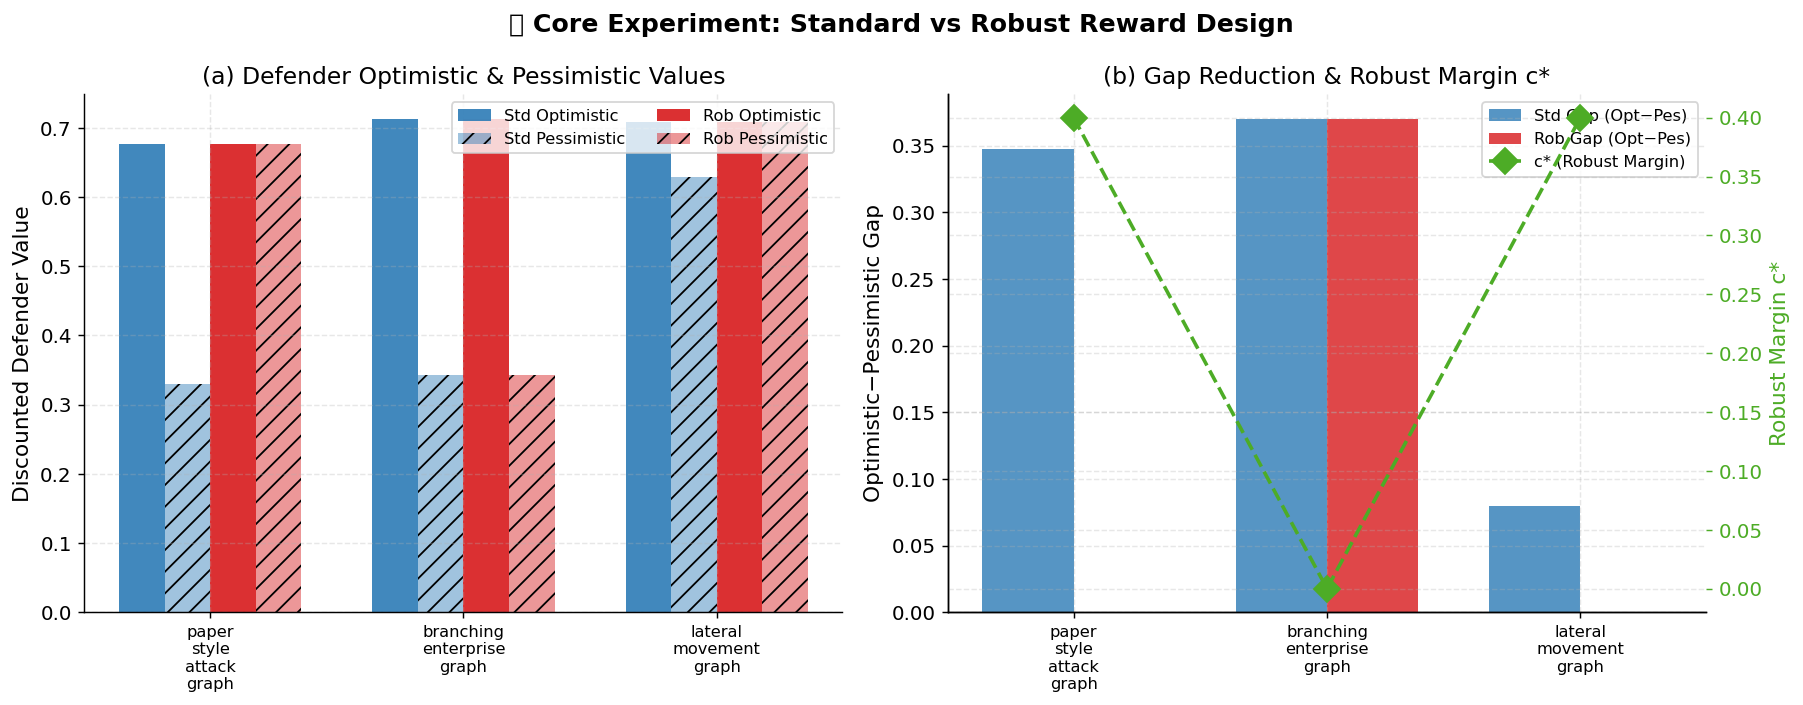

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\core_comparison_barplot.png


In [13]:
# ── 4.2 Biểu đồ cột: so sánh Opt/Pes values từng case ────────────────────
case_names = list(mdp_registry.keys())
n_cases    = len(case_names)
x_idx      = np.arange(n_cases)
bar_w      = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- (a) Defender Values ---
ax = axes[0]
std_opt = [value_summaries_std[c].defender_optimistic_value  for c in case_names]
std_pes = [value_summaries_std[c].defender_pessimistic_value for c in case_names]
rob_opt = [value_summaries_rob[c].defender_optimistic_value  for c in case_names]
rob_pes = [value_summaries_rob[c].defender_pessimistic_value for c in case_names]

ax.bar(x_idx - 1.5*bar_w, std_opt, bar_w, label="Std Optimistic",  color=COLOR_STANDARD, alpha=0.9)
ax.bar(x_idx - 0.5*bar_w, std_pes, bar_w, label="Std Pessimistic", color=COLOR_STANDARD, alpha=0.45, hatch="//")
ax.bar(x_idx + 0.5*bar_w, rob_opt, bar_w, label="Rob Optimistic",  color=COLOR_ROBUST,   alpha=0.9)
ax.bar(x_idx + 1.5*bar_w, rob_pes, bar_w, label="Rob Pessimistic", color=COLOR_ROBUST,   alpha=0.45, hatch="//")
ax.set_xticks(x_idx)
ax.set_xticklabels([c.replace("_", "\n") for c in case_names], fontsize=9)
ax.set_ylabel("Discounted Defender Value")
ax.set_title("(a) Defender Optimistic & Pessimistic Values")
ax.legend(fontsize=9, ncol=2)

# --- (b) Robust margin c* và gap reduction ---
ax = axes[1]
c_stars    = [robust_results[c].c_star for c in case_names]
std_gaps   = [value_summaries_std[c].defender_optimistic_value - value_summaries_std[c].defender_pessimistic_value for c in case_names]
rob_gaps   = [value_summaries_rob[c].defender_optimistic_value - value_summaries_rob[c].defender_pessimistic_value for c in case_names]

ax.bar(x_idx - bar_w, std_gaps, bar_w*2, label="Std Gap (Opt−Pes)", color=COLOR_STANDARD, alpha=0.8)
ax.bar(x_idx + bar_w, rob_gaps, bar_w*2, label="Rob Gap (Opt−Pes)", color=COLOR_ROBUST,   alpha=0.8)
ax2 = ax.twinx()
ax2.plot(x_idx, c_stars, "D--", color=COLOR_NEUTRAL, linewidth=2, markersize=10, label="c* (Robust Margin)", zorder=5)
ax2.set_ylabel("Robust Margin c*", color=COLOR_NEUTRAL)
ax2.tick_params(axis="y", colors=COLOR_NEUTRAL)
ax.set_xticks(x_idx)
ax.set_xticklabels([c.replace("_", "\n") for c in case_names], fontsize=9)
ax.set_ylabel("Optimistic−Pessimistic Gap")
ax.set_title("(b) Gap Reduction & Robust Margin c*")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

fig.suptitle("📊 Core Experiment: Standard vs Robust Reward Design", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = OUT_DIR / "core_comparison_barplot.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

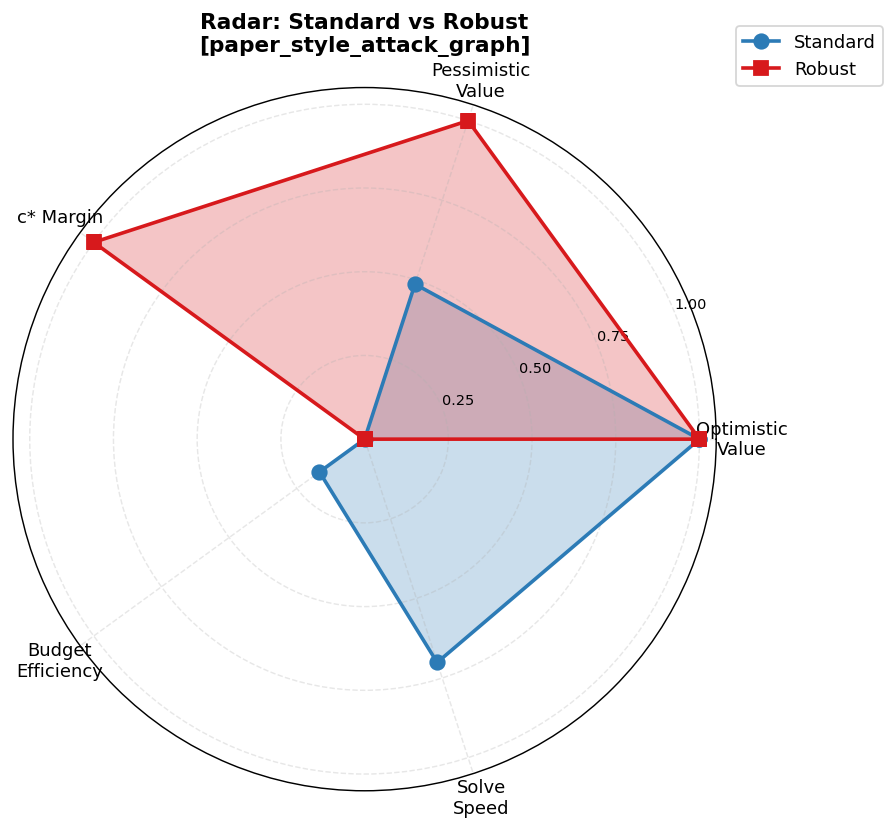

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\radar_standard_vs_robust.png


In [14]:
# ── 4.3 Radar chart: so sánh đa chiều Standard vs Robust trên case paper_style ─
from matplotlib.patches import FancyArrowPatch

name = "paper_style_attack_graph"
mdp  = mdp_registry[name]
std  = standard_results[name]
rob  = robust_results[name]
vs_s = value_summaries_std[name]
vs_r = value_summaries_rob[name]

categories  = ["Optimistic\nValue", "Pessimistic\nValue", "c* Margin", "Budget\nEfficiency", "Solve\nSpeed"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Normalisasi sang [0,1] dựa trên max của từng metric
max_val = max(vs_s.defender_optimistic_value, vs_r.defender_optimistic_value)
max_pes = max(abs(vs_s.defender_pessimistic_value), abs(vs_r.defender_pessimistic_value), 1e-9)
max_c   = max(rob.c_star, 1e-9)
max_rt  = max(std.runtime_seconds, rob.runtime_seconds, 1e-9)

std_vals = [
    vs_s.defender_optimistic_value  / max(max_val, 1e-9),
    vs_s.defender_pessimistic_value / max(max_pes, 1e-9),
    0.0,  # standard không có c*
    (mdp.budget - sum(std.x_milp.values())) / max(mdp.budget, 1e-9),
    1.0 - std.runtime_seconds / max(max_rt, 1e-9),
]
rob_vals = [
    vs_r.defender_optimistic_value  / max(max_val, 1e-9),
    vs_r.defender_pessimistic_value / max(max_pes, 1e-9),
    rob.c_star / max(max_c, 1e-9),
    (mdp.budget - sum(rob.x_ip.values())) / max(mdp.budget, 1e-9),
    1.0 - rob.runtime_seconds / max(max_rt, 1e-9),
]
std_vals += std_vals[:1]
rob_vals += rob_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.fill(angles, std_vals, alpha=0.25, color=COLOR_STANDARD)
ax.plot(angles, std_vals, "o-", linewidth=2, color=COLOR_STANDARD, label="Standard")
ax.fill(angles, rob_vals, alpha=0.25, color=COLOR_ROBUST)
ax.plot(angles, rob_vals, "s-", linewidth=2, color=COLOR_ROBUST, label="Robust")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
ax.set_title(f"Radar: Standard vs Robust\n[{name}]", fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
fig_path = OUT_DIR / "radar_standard_vs_robust.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

---
## 5. Budget Sweep — Tìm Phase Transition của Robust Solution

In [15]:
# ── 5.1 Chạy budget sweep ─────────────────────────────────────────────────
mdp_base     = load_mdp(BUDGET_SWEEP_BASE_CASE)
budget_sweep_records = []

print(f"📊 Budget Sweep trên case: {mdp_base.name}")
print(f"   Budget grid: {BUDGET_GRID}")
print("=" * 65)

for budget in BUDGET_GRID:
    mdp_b = mdp_base.with_budget(budget)
    print(f"  C={budget:.2f}", end=" → ", flush=True)
    
    std_b = solve_standard_reward_design(mdp_b, solver_msg=False, time_limit_seconds=TIME_LIMIT)
    rob_b = solve_max_margin_reward_design(mdp_b, v1_star=std_b.v1_star, solver_msg=False, time_limit_seconds=TIME_LIMIT)
    vs_b  = optimistic_and_pessimistic_values(mdp_b, rob_b.x_ip)
    vs_s  = optimistic_and_pessimistic_values(mdp_b, std_b.x_milp)
    
    print(f"v1*={std_b.v1_star:.4f}  c*={rob_b.c_star:.4f}  std_pes={vs_s.defender_pessimistic_value:.4f}  rob_pes={vs_b.defender_pessimistic_value:.4f}")
    
    budget_sweep_records.append({
        "budget"                        : budget,
        "v1_star"                       : std_b.v1_star,
        "c_star"                        : rob_b.c_star,
        "standard_optimistic_value"     : vs_s.defender_optimistic_value,
        "standard_pessimistic_value"    : vs_s.defender_pessimistic_value,
        "robust_optimistic_value"       : vs_b.defender_optimistic_value,
        "robust_pessimistic_value"      : vs_b.defender_pessimistic_value,
        "std_runtime"                   : std_b.runtime_seconds,
        "rob_runtime"                   : rob_b.runtime_seconds,
    })

df_budget = pd.DataFrame(budget_sweep_records)
print("\n✅ Budget sweep hoàn tất.")
df_budget

📊 Budget Sweep trên case: paper_style_attack_graph
   Budget grid: [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 3.0, 4.0, 5.0]
  C=0.30 → v1*=0.3292  c*=0.1500  std_pes=0.3292  rob_pes=0.3292
  C=0.60 → v1*=0.3387  c*=0.0400  std_pes=0.3292  rob_pes=0.3387
  C=0.90 → v1*=0.6233  c*=0.0200  std_pes=0.5950  rob_pes=0.6233
  C=1.20 → v1*=0.6233  c*=0.1600  std_pes=0.5950  rob_pes=0.6233
  C=1.50 → v1*=0.6602  c*=0.1000  std_pes=0.5967  rob_pes=0.6602
  C=1.80 → v1*=0.6602  c*=0.2800  std_pes=0.5967  rob_pes=0.6602
  C=2.10 → v1*=0.6765  c*=0.1000  std_pes=0.3292  rob_pes=0.6765
  C=2.40 → v1*=0.6765  c*=0.4000  std_pes=0.3292  rob_pes=0.6765
  C=3.00 → v1*=0.6765  c*=1.0000  std_pes=0.3292  rob_pes=0.6765
  C=4.00 → v1*=0.6765  c*=1.3333  std_pes=0.3292  rob_pes=0.6765
  C=5.00 → v1*=0.6765  c*=1.6667  std_pes=0.3292  rob_pes=0.6765

✅ Budget sweep hoàn tất.


,budget,v1_star,c_star,standard_optimistic_value,standard_pessimistic_value,robust_optimistic_value,robust_pessimistic_value,std_runtime,rob_runtime
0,0.3,0.329232,0.150000,0.329232,0.329232,0.329232,0.329232,0.101111,0.098322
1,0.6,0.338663,0.040000,0.338663,0.329232,0.338663,0.338662,0.098547,0.450866
2,0.9,0.623312,0.020000,0.623312,0.595015,0.623312,0.623307,0.104916,0.585856
3,1.2,0.623312,0.160000,0.623312,0.595015,0.623312,0.623311,0.088010,0.740418
4,1.5,0.660179,0.100000,0.660179,0.596733,0.660179,0.660178,0.188228,0.604714
5,1.8,0.660179,0.280000,0.660179,0.596733,0.660179,0.660178,0.222196,0.905423
6,2.1,0.676469,0.100000,0.676469,0.329232,0.676469,0.676467,0.046441,0.442630
7,2.4,0.676469,0.400000,0.676469,0.329232,0.676469,0.676468,0.043017,0.460004
8,3.0,0.676469,1.000000,0.676469,0.329232,0.676469,0.676469,0.046958,0.779150
9,4.0,0.676469,1.333333,0.676469,0.329232,0.676469,0.676469,0.040286,0.442873


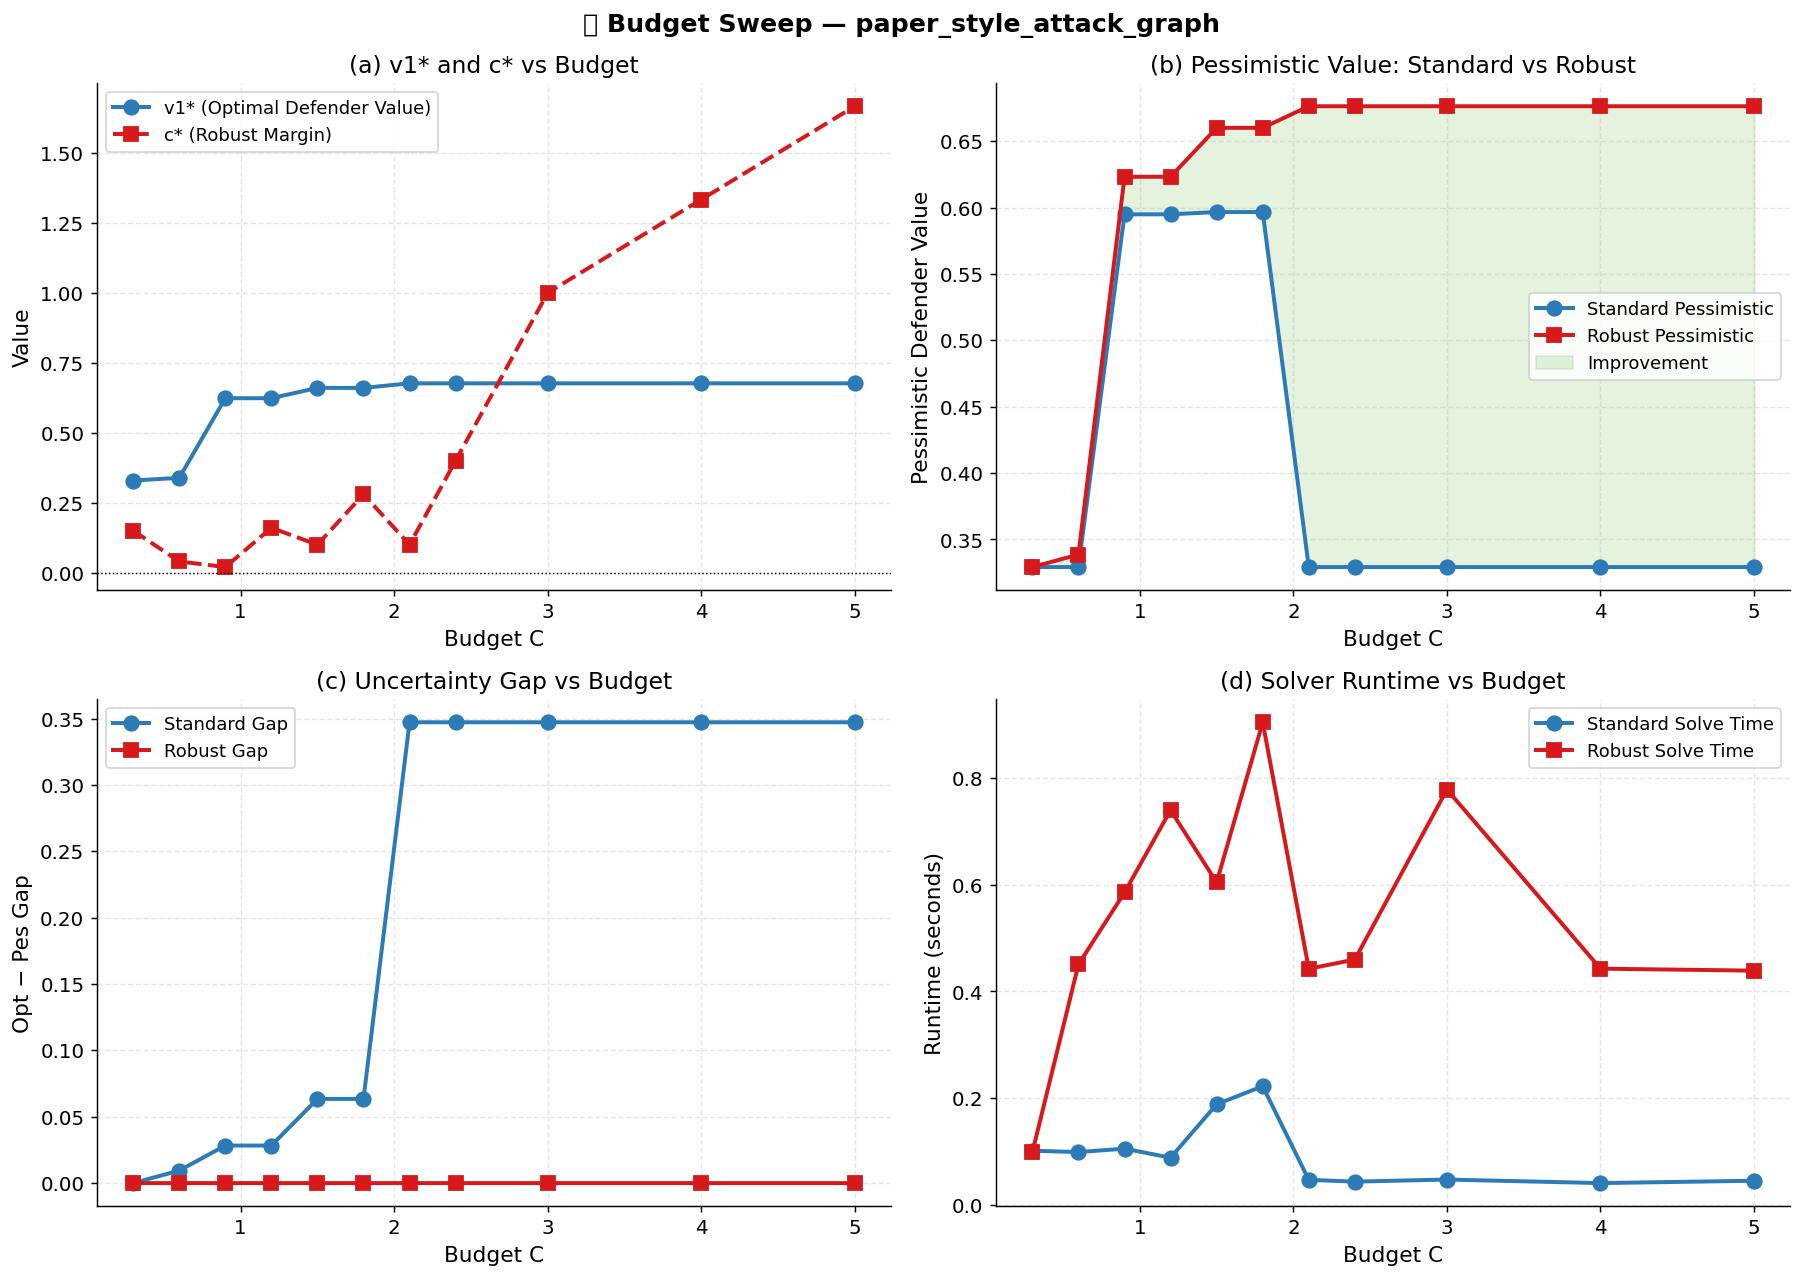

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\budget_sweep_full.png


In [16]:
# ── 5.2 Vẽ biểu đồ budget sweep đầy đủ ───────────────────────────────────
budgets = df_budget["budget"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (a) v1* và c* theo budget ---
ax = axes[0, 0]
ax.plot(budgets, df_budget["v1_star"], "o-", color=COLOR_STANDARD, label="v1* (Optimal Defender Value)")
ax.plot(budgets, df_budget["c_star"],  "s--", color=COLOR_ROBUST, label="c* (Robust Margin)")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Budget C")
ax.set_ylabel("Value")
ax.set_title("(a) v1* and c* vs Budget")
ax.legend()

# --- (b) Pessimistic value: Standard vs Robust ---
ax = axes[0, 1]
ax.plot(budgets, df_budget["standard_pessimistic_value"], "o-", color=COLOR_STANDARD, label="Standard Pessimistic")
ax.plot(budgets, df_budget["robust_pessimistic_value"],   "s-", color=COLOR_ROBUST,   label="Robust Pessimistic")
ax.fill_between(budgets,
                df_budget["standard_pessimistic_value"],
                df_budget["robust_pessimistic_value"],
                alpha=0.15, color=COLOR_NEUTRAL, label="Improvement")
ax.set_xlabel("Budget C")
ax.set_ylabel("Pessimistic Defender Value")
ax.set_title("(b) Pessimistic Value: Standard vs Robust")
ax.legend()

# --- (c) Gap (Opt − Pes) ---
ax = axes[1, 0]
std_gaps = df_budget["standard_optimistic_value"] - df_budget["standard_pessimistic_value"]
rob_gaps = df_budget["robust_optimistic_value"]   - df_budget["robust_pessimistic_value"]
ax.plot(budgets, std_gaps, "o-", color=COLOR_STANDARD, label="Standard Gap")
ax.plot(budgets, rob_gaps, "s-", color=COLOR_ROBUST,   label="Robust Gap")
ax.set_xlabel("Budget C")
ax.set_ylabel("Opt − Pes Gap")
ax.set_title("(c) Uncertainty Gap vs Budget")
ax.legend()

# --- (d) Solve time ---
ax = axes[1, 1]
ax.plot(budgets, df_budget["std_runtime"], "o-", color=COLOR_STANDARD, label="Standard Solve Time")
ax.plot(budgets, df_budget["rob_runtime"], "s-", color=COLOR_ROBUST,   label="Robust Solve Time")
ax.set_xlabel("Budget C")
ax.set_ylabel("Runtime (seconds)")
ax.set_title("(d) Solver Runtime vs Budget")
ax.legend()

fig.suptitle(f"📈 Budget Sweep — {mdp_base.name}", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = OUT_DIR / "budget_sweep_full.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

---
## 6. Bounded-Rational Attacker — τ Sweep

In [17]:
# ── 6.1 Chạy τ sweep cho tất cả cases ────────────────────────────────────
tau_sweep_data: Dict[str, List[dict]] = {}

print(f"⏩ τ Sweep — Bounded Rationality Analysis")
print(f"   τ grid: {TAU_GRID}")
print("=" * 65)

for name, mdp in mdp_registry.items():
    std = standard_results[name]
    rob = robust_results[name]
    records = []
    print(f"\n  [{name}]")
    
    for tau in TAU_GRID:
        std_soft = soft_response_summary(mdp, std.x_milp, tau)
        rob_soft = soft_response_summary(mdp, rob.x_ip,   tau)
        absorb_std = absorption_probabilities(mdp, soft_value_iteration(mdp, std.x_milp, tau))
        absorb_rob = absorption_probabilities(mdp, soft_value_iteration(mdp, rob.x_ip,   tau))
        
        records.append({
            "tau"                           : tau,
            "standard_defender_value"       : std_soft.defender_value,
            "robust_defender_value"         : rob_soft.defender_value,
            "standard_true_goal_prob"       : std_soft.true_goal_probability,
            "robust_true_goal_prob"         : rob_soft.true_goal_probability,
            "standard_decoy_prob"           : std_soft.decoy_probability,
            "robust_decoy_prob"             : rob_soft.decoy_probability,
            "std_rob_value_diff"            : rob_soft.defender_value - std_soft.defender_value,
            "std_true_goal_minus_rob"       : std_soft.true_goal_probability - rob_soft.true_goal_probability,
        })
        print(f"    τ={tau:.3f} → std_val={std_soft.defender_value:.5f}  rob_val={rob_soft.defender_value:.5f}  std_tgp={std_soft.true_goal_probability:.4f}  rob_tgp={rob_soft.true_goal_probability:.4f}")
    
    tau_sweep_data[name] = records

print("\n✅ τ sweep hoàn tất.")

⏩ τ Sweep — Bounded Rationality Analysis
   τ grid: [2.0, 1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]

  [paper_style_attack_graph]
    τ=2.000 → std_val=0.55260  rob_val=0.55444  std_tgp=0.3555  rob_tgp=0.3533
    τ=1.000 → std_val=0.55260  rob_val=0.55632  std_tgp=0.3555  rob_tgp=0.3511
    τ=0.500 → std_val=0.55260  rob_val=0.56020  std_tgp=0.3555  rob_tgp=0.3466
    τ=0.200 → std_val=0.55260  rob_val=0.57253  std_tgp=0.3555  rob_tgp=0.3322
    τ=0.100 → std_val=0.55260  rob_val=0.59309  std_tgp=0.3555  rob_tgp=0.3082
    τ=0.050 → std_val=0.55260  rob_val=0.62338  std_tgp=0.3555  rob_tgp=0.2729
    τ=0.020 → std_val=0.55260  rob_val=0.65909  std_tgp=0.3555  rob_tgp=0.2313
    τ=0.010 → std_val=0.55260  rob_val=0.67238  std_tgp=0.3555  rob_tgp=0.2158
    τ=0.005 → std_val=0.55260  rob_val=0.67534  std_tgp=0.3555  rob_tgp=0.2123

  [branching_enterprise_graph]
    τ=2.000 → std_val=0.55235  rob_val=0.55235  std_tgp=0.3618  rob_tgp=0.3618
    τ=1.000 → std_val=0.55240  rob_val=0.5524

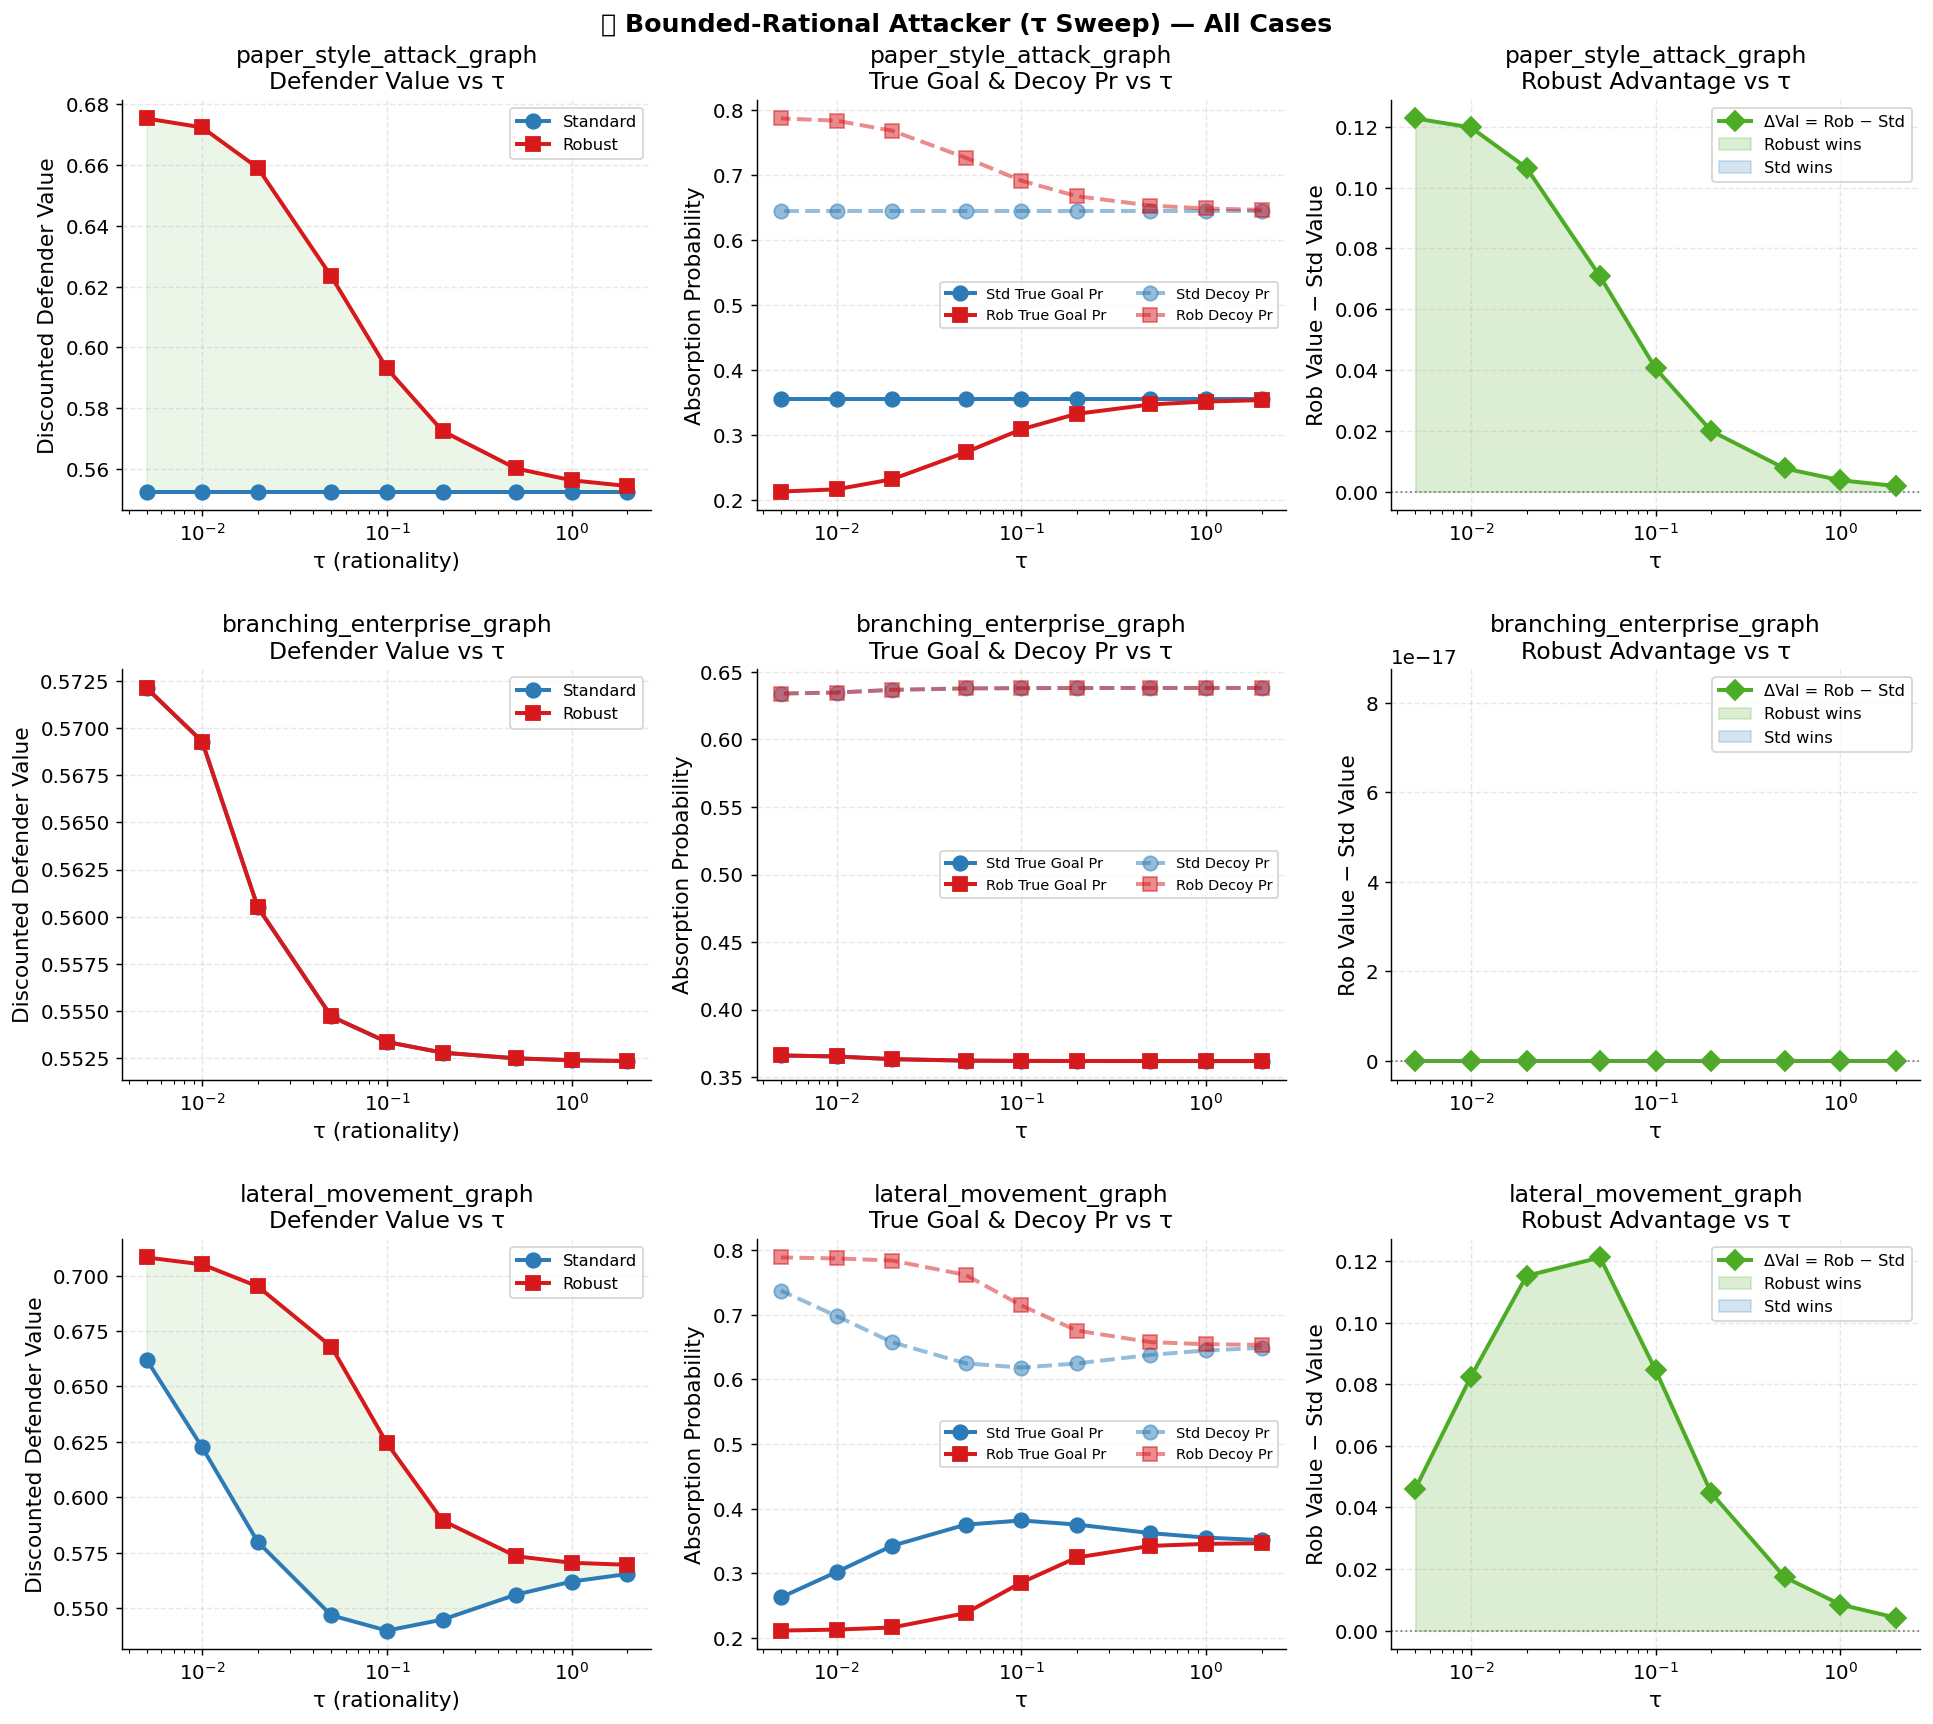

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\tau_sweep_full.png


In [18]:
# ── 6.2 Vẽ τ sweep đầy đủ cho tất cả cases ───────────────────────────────
n_cases = len(mdp_registry)
fig, axes = plt.subplots(n_cases, 3, figsize=(15, 4.5 * n_cases))
if n_cases == 1:
    axes = [axes]

for row_idx, (name, records) in enumerate(tau_sweep_data.items()):
    df_tau = pd.DataFrame(records)
    taus = df_tau["tau"]

    # --- Col 0: Defender value ---
    ax = axes[row_idx][0]
    ax.semilogx(taus, df_tau["standard_defender_value"], "o-", color=COLOR_STANDARD, label="Standard")
    ax.semilogx(taus, df_tau["robust_defender_value"],   "s-", color=COLOR_ROBUST,   label="Robust")
    ax.fill_between(taus, df_tau["standard_defender_value"], df_tau["robust_defender_value"],
                    alpha=0.1, color=COLOR_NEUTRAL)
    ax.set_xlabel("τ (rationality)");  ax.set_ylabel("Discounted Defender Value")
    ax.set_title(f"{name}\nDefender Value vs τ")
    ax.legend(fontsize=9)

    # --- Col 1: True goal probability ---
    ax = axes[row_idx][1]
    ax.semilogx(taus, df_tau["standard_true_goal_prob"], "o-", color=COLOR_STANDARD, label="Std True Goal Pr")
    ax.semilogx(taus, df_tau["robust_true_goal_prob"],   "s-", color=COLOR_ROBUST,   label="Rob True Goal Pr")
    ax.semilogx(taus, df_tau["standard_decoy_prob"],     "o--", color=COLOR_STANDARD, alpha=0.5, label="Std Decoy Pr")
    ax.semilogx(taus, df_tau["robust_decoy_prob"],       "s--", color=COLOR_ROBUST,   alpha=0.5, label="Rob Decoy Pr")
    ax.set_xlabel("τ"); ax.set_ylabel("Absorption Probability")
    ax.set_title(f"{name}\nTrue Goal & Decoy Pr vs τ")
    ax.legend(fontsize=8, ncol=2)

    # --- Col 2: Difference (Robust - Standard) ---
    ax = axes[row_idx][2]
    diff_val   = df_tau["std_rob_value_diff"]
    diff_tgp   = df_tau["std_true_goal_minus_rob"]  # positive = robust có ít true_goal hơn (tốt)
    ax.semilogx(taus, diff_val, "D-", color=COLOR_NEUTRAL, label="ΔVal = Rob − Std")
    ax.axhline(0, color="gray", linewidth=1, linestyle=":")
    ax.fill_between(taus, 0, diff_val, where=diff_val>=0, alpha=0.2, color=COLOR_NEUTRAL, label="Robust wins")
    ax.fill_between(taus, 0, diff_val, where=diff_val<0,  alpha=0.2, color=COLOR_STANDARD, label="Std wins")
    ax.set_xlabel("τ"); ax.set_ylabel("Rob Value − Std Value")
    ax.set_title(f"{name}\nRobust Advantage vs τ")
    ax.legend(fontsize=9)

fig.suptitle("🧠 Bounded-Rational Attacker (τ Sweep) — All Cases", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = OUT_DIR / "tau_sweep_full.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

---
## 7. Reward Perception Sensitivity — ε Sweep (Perturbation Analysis)

In [19]:
# ── 7.1 Chạy ε sweep cho Standard và Robust trên tất cả cases ─────────────
perturb_data_std: Dict[str, List[PerturbationSummary]] = {}
perturb_data_rob: Dict[str, List[PerturbationSummary]] = {}

print(f"📊 Reward Perception Sweep (ε perturbation)")
print(f"   ε grid: {EPS_GRID}")
print(f"   Samples/ε: {SAMPLES_PER_EPS}")
print("=" * 65)

for name, mdp in mdp_registry.items():
    std = standard_results[name]
    rob = robust_results[name]
    print(f"  [{name}]...", end=" ", flush=True)
    
    ps  = reward_perception_sweep(mdp, std.x_milp, EPS_GRID, SAMPLES_PER_EPS, seed=PERTURB_SEED)
    pr  = reward_perception_sweep(mdp, rob.x_ip,   EPS_GRID, SAMPLES_PER_EPS, seed=PERTURB_SEED)
    perturb_data_std[name] = ps
    perturb_data_rob[name] = pr
    print("Done")

print("\n✅ ε sweep hoàn tất.")

📊 Reward Perception Sweep (ε perturbation)
   ε grid: [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
   Samples/ε: 30
  [paper_style_attack_graph]... Done
  [branching_enterprise_graph]... Done
  [lateral_movement_graph]... Done

✅ ε sweep hoàn tất.


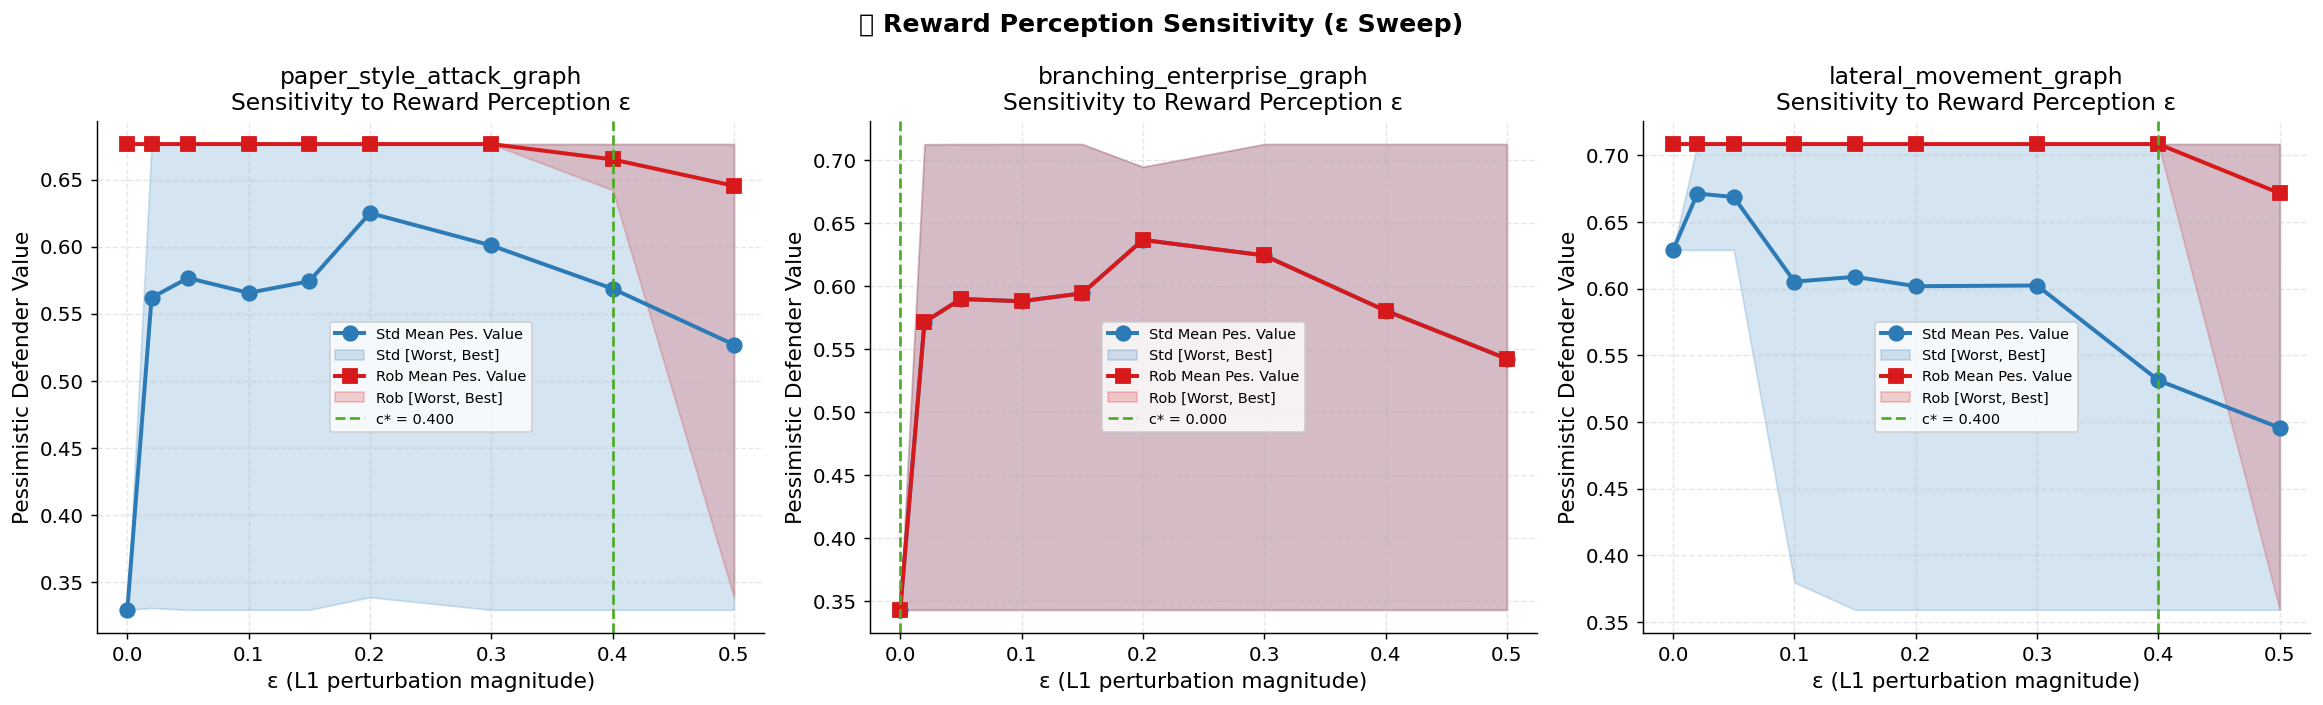

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\epsilon_sweep_full.png


In [20]:
# ── 7.2 Vẽ ε sweep với confidence band ───────────────────────────────────
n_cases = len(mdp_registry)
fig, axes = plt.subplots(1, n_cases, figsize=(6 * n_cases, 5.5))
if n_cases == 1:
    axes = [axes]

for ax, name in zip(axes, mdp_registry.keys()):
    ps = perturb_data_std[name]
    pr = perturb_data_rob[name]
    c_star = robust_results[name].c_star
    
    eps_vals = [p.epsilon for p in ps]
    
    # Standard: avg ± (best - worst) / 2
    std_avg  = [p.avg_pessimistic_value  for p in ps]
    std_best = [p.best_pessimistic_value for p in ps]
    std_wst  = [p.worst_pessimistic_value for p in ps]
    rob_avg  = [p.avg_pessimistic_value  for p in pr]
    rob_best = [p.best_pessimistic_value for p in pr]
    rob_wst  = [p.worst_pessimistic_value for p in pr]
    
    ax.plot(eps_vals, std_avg, "o-",  color=COLOR_STANDARD, label="Std Mean Pes. Value")
    ax.fill_between(eps_vals, std_wst, std_best, alpha=0.2, color=COLOR_STANDARD, label="Std [Worst, Best]")
    ax.plot(eps_vals, rob_avg, "s-",  color=COLOR_ROBUST,   label="Rob Mean Pes. Value")
    ax.fill_between(eps_vals, rob_wst, rob_best, alpha=0.2, color=COLOR_ROBUST,   label="Rob [Worst, Best]")
    
    # Đánh dấu c* trên trục x
    ax.axvline(c_star, color=COLOR_NEUTRAL, linestyle="--", linewidth=1.5, label=f"c* = {c_star:.3f}")
    ax.set_xlabel("ε (L1 perturbation magnitude)")
    ax.set_ylabel("Pessimistic Defender Value")
    ax.set_title(f"{name}\nSensitivity to Reward Perception ε")
    ax.legend(fontsize=8)

fig.suptitle("🔍 Reward Perception Sensitivity (ε Sweep)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = OUT_DIR / "epsilon_sweep_full.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

In [21]:
# ── 7.3 Bảng epsilon sensitivity chi tiết ────────────────────────────────
eps_table_rows = []
for name in mdp_registry:
    c_star = robust_results[name].c_star
    for p_std, p_rob in zip(perturb_data_std[name], perturb_data_rob[name]):
        eps_table_rows.append({
            "Case"              : name,
            "ε"                 : p_std.epsilon,
            "c* threshold"      : round(c_star, 5),
            "ε < c*"            : "✓" if p_std.epsilon <= c_star else "✗",
            "Std Avg Pes"       : round(p_std.avg_pessimistic_value, 5),
            "Std Worst Pes"     : round(p_std.worst_pessimistic_value, 5),
            "Rob Avg Pes"       : round(p_rob.avg_pessimistic_value, 5),
            "Rob Worst Pes"     : round(p_rob.worst_pessimistic_value, 5),
            "Rob − Std (Avg)"   : round(p_rob.avg_pessimistic_value - p_std.avg_pessimistic_value, 5),
        })

df_eps = pd.DataFrame(eps_table_rows)
print("📋 Epsilon Sensitivity Table")
df_eps

📋 Epsilon Sensitivity Table


,Case,ε,c* threshold,ε < c*,Std Avg Pes,Std Worst Pes,Rob Avg Pes,Rob Worst Pes,Rob − Std (Avg)
0,paper_style_attack_graph,0.00,0.4,✓,0.32923,0.32923,0.67647,0.67647,0.34724
1,paper_style_attack_graph,0.02,0.4,✓,0.56193,0.33062,0.67647,0.67647,0.11454
2,paper_style_attack_graph,0.05,0.4,✓,0.57664,0.32923,0.67647,0.67647,0.09983
3,paper_style_attack_graph,0.10,0.4,✓,0.56555,0.32923,0.67647,0.67647,0.11092
4,paper_style_attack_graph,0.15,0.4,✓,0.57418,0.32923,0.67647,0.67647,0.10229
5,paper_style_attack_graph,0.20,0.4,✓,0.62503,0.33866,0.67647,0.67647,0.05144
6,paper_style_attack_graph,0.30,0.4,✓,0.60089,0.32923,0.67647,0.67647,0.07558
7,paper_style_attack_graph,0.40,0.4,✓,0.56864,0.32923,0.66504,0.64216,0.09640
8,paper_style_attack_graph,0.50,0.4,✗,0.52694,0.32923,0.64533,0.33848,0.11838
9,branching_enterprise_graph,0.00,0.0,✓,0.34295,0.34295,0.34295,0.34295,0.00000


---
## 8. Phân Tích Intervention Sites

In [22]:
# ── 8.1 Tính điểm (score) cho từng intervention site ─────────────────────
intervention_scores: Dict[str, List[SiteScore]] = {}

print("🏅 Intervention Site Scoring")
print("=" * 65)

for name, mdp in mdp_registry.items():
    scores = score_interventions(mdp)
    intervention_scores[name] = scores
    print(f"\n  [{name}]")
    print(f"  {'Site':<20} {'Score':>8} {'Reach':>8} {'Centrality':>12} {'Proximity':>10}")
    print(f"  {'-'*60}")
    for s in scores:
        pair_str = f"({mdp.label(s.pair[0])}, {s.pair[1]})"
        print(f"  {pair_str:<20} {s.score:>8.5f} {s.reach:>8.5f} {s.centrality:>12.5f} {s.proximity:>10.5f}")

🏅 Intervention Site Scoring

  [paper_style_attack_graph]
  Site                    Score    Reach   Centrality  Proximity
  ------------------------------------------------------------
  (decoy_1, end)        0.37397  0.18948      0.00631    0.09091
  (decoy_2, end)        0.34852  0.13975      0.01389    0.09091

  [branching_enterprise_graph]
  Site                    Score    Reach   Centrality  Proximity
  ------------------------------------------------------------
  (fake_backup_server, end)  0.38153  0.19767      0.01852    0.09091
  (honeypot_admin, end)  0.32241  0.09776      0.00185    0.09091

  [lateral_movement_graph]
  Site                    Score    Reach   Centrality  Proximity
  ------------------------------------------------------------
  (decoy_file_server, end)  0.37604  0.19189      0.00926    0.09091
  (decoy_mail_server, end)  0.33901  0.12457      0.00926    0.09091


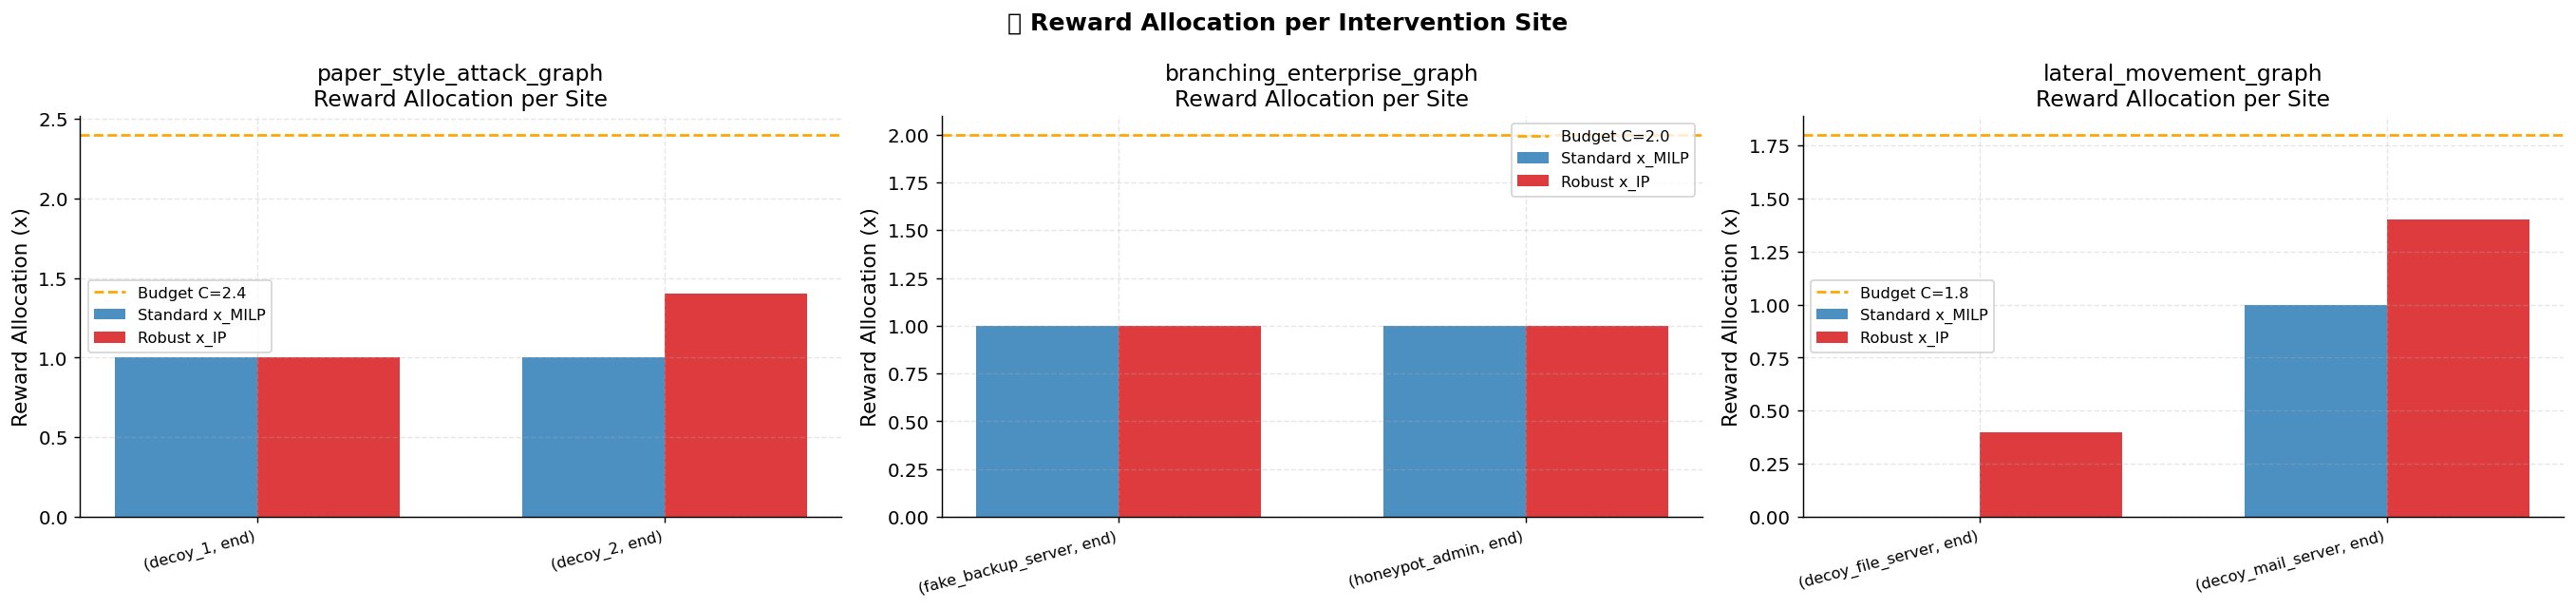

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\allocation_comparison.png


In [23]:
# ── 8.2 Vẽ biểu đồ phân bổ Standard và Robust theo site ─────────────────
fig, axes = plt.subplots(1, len(mdp_registry), figsize=(7 * len(mdp_registry), 5))
if len(mdp_registry) == 1:
    axes = [axes]

for ax, (name, mdp) in zip(axes, mdp_registry.items()):
    sites  = [f"({mdp.label(it.state)}, {it.action})" for it in mdp.interventions]
    x_pos  = np.arange(len(sites))
    bar_w  = 0.35

    std_alloc = [standard_results[name].x_milp.get(it.pair, 0.0) for it in mdp.interventions]
    rob_alloc = [robust_results[name].x_ip.get(it.pair, 0.0)     for it in mdp.interventions]

    ax.bar(x_pos - bar_w/2, std_alloc, bar_w, label="Standard x_MILP", color=COLOR_STANDARD, alpha=0.85)
    ax.bar(x_pos + bar_w/2, rob_alloc, bar_w, label="Robust x_IP",     color=COLOR_ROBUST,   alpha=0.85)
    ax.axhline(mdp.budget, color="orange", linestyle="--", linewidth=1.5, label=f"Budget C={mdp.budget}")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sites, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Reward Allocation (x)")
    ax.set_title(f"{name}\nReward Allocation per Site")
    ax.legend(fontsize=9)

fig.suptitle("🎯 Reward Allocation per Intervention Site", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = OUT_DIR / "allocation_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: {fig_path}")

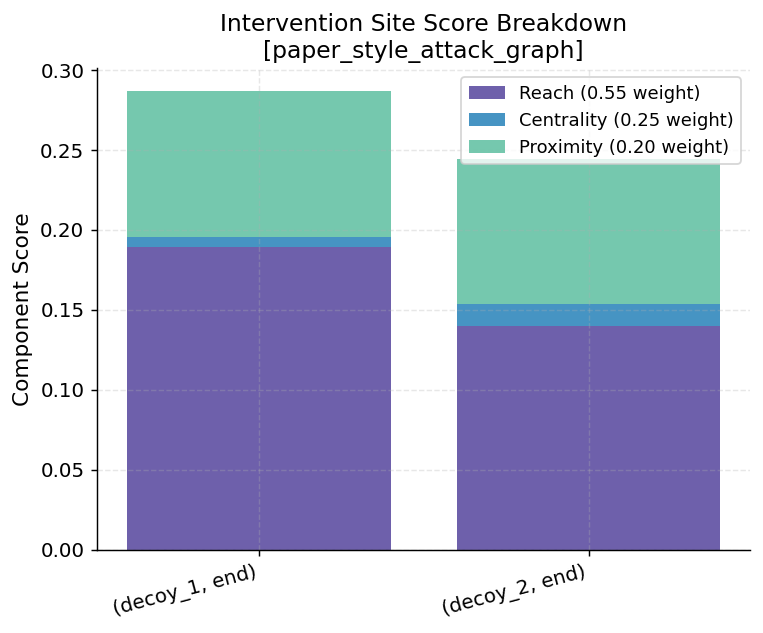

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\site_score_breakdown.png


In [24]:
# ── 8.3 Stacked bar: Breakdown theo reach / centrality / proximity ────────
name  = "paper_style_attack_graph"
mdp   = mdp_registry[name]
scores = intervention_scores[name]

if scores:
    site_labels = [f"({mdp.label(s.pair[0])}, {s.pair[1]})" for s in scores]
    reaches     = [s.reach      for s in scores]
    cents       = [s.centrality for s in scores]
    prox_scaled = [s.proximity  for s in scores]

    x_pos = np.arange(len(scores))
    fig, ax = plt.subplots(figsize=(max(6, len(scores) * 2.5), 5))
    p1 = ax.bar(x_pos, reaches,     label="Reach (0.55 weight)",      color="#5E4FA2", alpha=0.9)
    p2 = ax.bar(x_pos, cents,       label="Centrality (0.25 weight)", color="#3288BD", alpha=0.9, bottom=reaches)
    p3 = ax.bar(x_pos, prox_scaled, label="Proximity (0.20 weight)",  color="#66C2A5", alpha=0.9,
                bottom=[r + c for r, c in zip(reaches, cents)])
    ax.set_xticks(x_pos)
    ax.set_xticklabels(site_labels, rotation=15, ha="right")
    ax.set_ylabel("Component Score")
    ax.set_title(f"Intervention Site Score Breakdown\n[{name}]")
    ax.legend()
    plt.tight_layout()
    fig_path = OUT_DIR / "site_score_breakdown.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Đã lưu: {fig_path}")

---
## 9. Scalable Heuristics — Large Enterprise Graphs

In [25]:
# ── 9.1 Load large graph configs ──────────────────────────────────────────
large_mdp_registry: Dict[str, AttackGraphMDP] = {}

print("Loading large enterprise graph configs...")
for cfg_path in LARGE_CASE_CONFIGS:
    try:
        mdp = load_mdp(cfg_path)
        large_mdp_registry[mdp.name] = mdp
        print(f"  ✅ [{mdp.name}] — {len(mdp.states)} states, {len(mdp.sa_pairs)} SA-pairs, {len(mdp.interventions)} interventions")
    except Exception as e:
        print(f"  ❌ [{cfg_path}]: {e}")

Loading large enterprise graph configs...
  ✅ [large_enterprise_64] — 65 states, 188 SA-pairs, 10 interventions
  ✅ [large_enterprise_120] — 121 states, 328 SA-pairs, 16 interventions


In [26]:
# ── 9.2 Chạy Scalable Heuristic Pipeline ─────────────────────────────────
scalable_results = {}

print("🚀 Scalable Heuristic Pipeline (topk_slack_allocation)")
print("=" * 65)

for name, mdp in large_mdp_registry.items():
    print(f"\n  [{name}]...", end=" ", flush=True)
    t0 = perf_counter()
    result = run_scalable_pipeline(mdp, top_k_options=[4, 6, 8], reserve_options=[0.1, 0.15, 0.2])
    elapsed = perf_counter() - t0
    scalable_results[name] = result
    print(f"Done [{elapsed:.2f}s]")
    print(f"    Top-K used       : {result.num_interventions_used}")
    print(f"    Reserve ratio    : {result.reserve_ratio}")
    print(f"    Optimistic value : {result.optimistic_value:.5f}")
    print(f"    Pessimistic value: {result.pessimistic_value:.5f}")
    print(f"    Empirical margin : {result.empirical_margin:.5f}")
    print(f"    τ=0.05 true goal prob: {result.tau05_true_goal_prob:.4f}")
    print(f"    τ=0.05 decoy prob    : {result.tau05_decoy_prob:.4f}")

print("\n✅ Heuristic pipeline hoàn tất.")

🚀 Scalable Heuristic Pipeline (topk_slack_allocation)

  [large_enterprise_64]... Done [95.13s]
    Top-K used       : 4
    Reserve ratio    : 0.1
    Optimistic value : 0.79930
    Pessimistic value: 0.79926
    Empirical margin : 0.50000
    τ=0.05 true goal prob: 0.0006
    τ=0.05 decoy prob    : 0.9969

  [large_enterprise_120]... Done [124.81s]
    Top-K used       : 4
    Reserve ratio    : 0.1
    Optimistic value : 0.79930
    Pessimistic value: 0.79930
    Empirical margin : 0.50000
    τ=0.05 true goal prob: 0.0000
    τ=0.05 decoy prob    : 1.0000

✅ Heuristic pipeline hoàn tất.


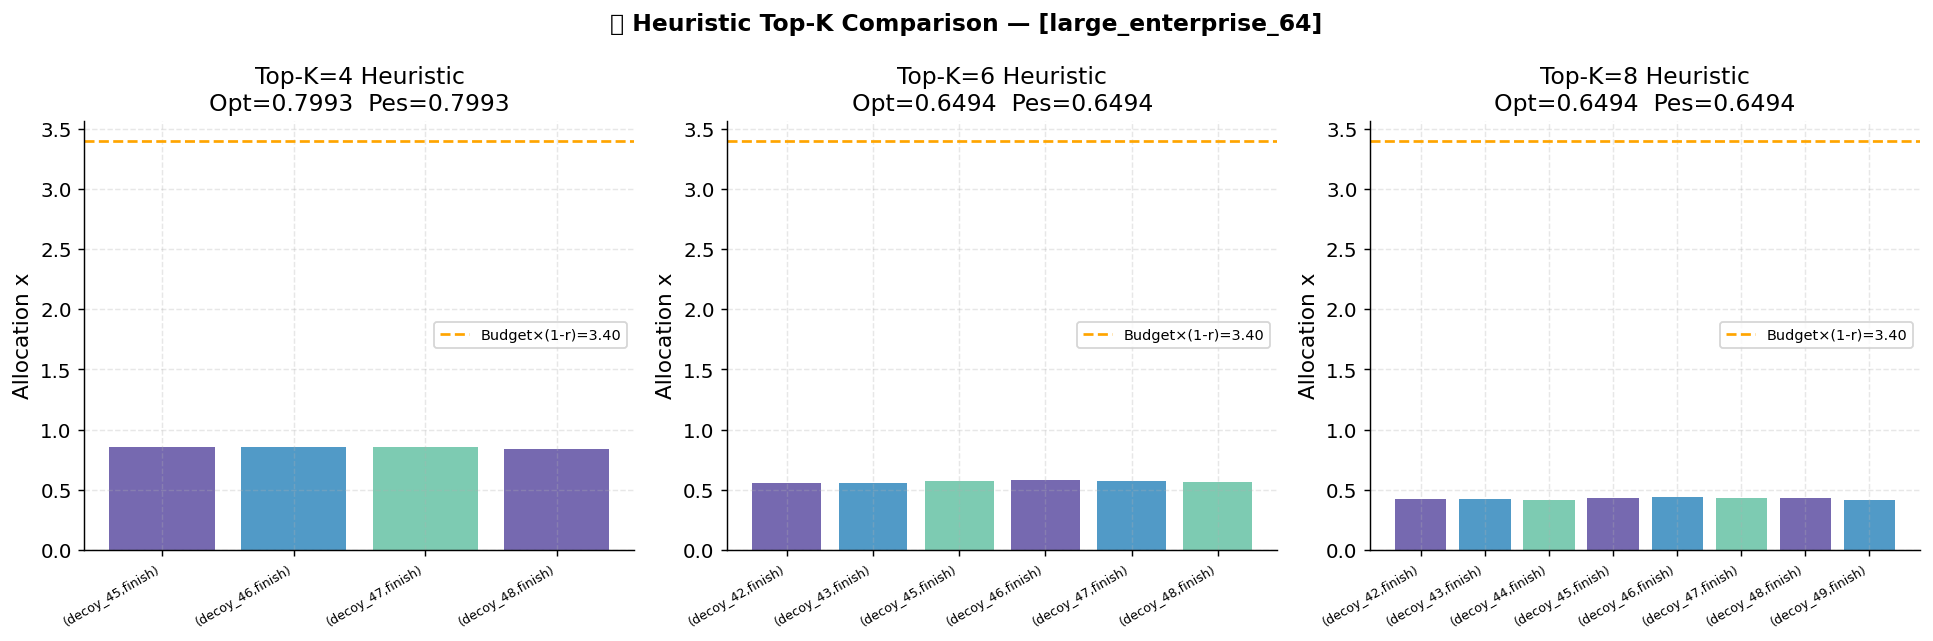

💾 Đã lưu: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\heuristic_topk_comparison.png


In [27]:
# ── 9.3 So sánh phân bổ heuristic cho các lựa chọn top-K khác nhau ───────
if large_mdp_registry:
    name = list(large_mdp_registry.keys())[0]
    mdp  = large_mdp_registry[name]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    topk_vals = [4, 6, 8]
    reserve   = 0.15
    
    for ax, k in zip(axes, topk_vals):
        x_alloc = topk_slack_allocation(mdp, top_k=k, reserve_ratio=reserve)
        vals    = optimistic_and_pessimistic_values(mdp, x_alloc)
        
        sites = [f"({mdp.label(it.state)},{it.action})" for it in mdp.interventions]
        allocs = [x_alloc.get(it.pair, 0.0) for it in mdp.interventions]
        
        # Chỉ hiện các site có phân bổ > 0
        nonzero_mask = [a > 1e-6 for a in allocs]
        sites_nz  = [s for s, m in zip(sites, nonzero_mask) if m]
        allocs_nz = [a for a, m in zip(allocs, nonzero_mask) if m]
        
        colors_bar = [CASE_COLORS[i % len(CASE_COLORS)] for i in range(len(sites_nz))]
        ax.bar(range(len(sites_nz)), allocs_nz, color=colors_bar, alpha=0.85)
        ax.set_xticks(range(len(sites_nz)))
        ax.set_xticklabels(sites_nz, rotation=30, ha="right", fontsize=7)
        ax.set_title(f"Top-K={k} Heuristic\nOpt={vals.defender_optimistic_value:.4f}  Pes={vals.defender_pessimistic_value:.4f}")
        ax.set_ylabel("Allocation x")
        ax.axhline(mdp.budget * (1 - reserve), color="orange", linestyle="--", linewidth=1.5,
                   label=f"Budget×(1-r)={mdp.budget*(1-reserve):.2f}")
        ax.legend(fontsize=8)

    fig.suptitle(f"🔬 Heuristic Top-K Comparison — [{name}]", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig_path = OUT_DIR / "heuristic_topk_comparison.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Đã lưu: {fig_path}")

---
## 10. Bảng Tổng Hợp Cho Paper

In [28]:
# ── 10.1 Table 1: Notation và Giả thiết mô hình ───────────────────────────
notation_data = [
    ("S",         "Tập trạng thái (states) của MDP"),
    ("A",         "Tập hành động (actions) của Attacker"),
    ("P(s'|s,a)", "Xác suất chuyển trạng thái"),
    ("γ",         "Hệ số chiết khấu (discount factor) ∈ (0,1)"),
    ("r₂(s,a)",   "Phần thưởng cơ sở của Attacker"),
    ("r₁(s,a)",   "Phần thưởng cơ sở của Defender"),
    ("D",         "Tập các state-action pairs được can thiệp"),
    ("C",         "Ngân sách can thiệp của Defender"),
    ("x",         "Vector phân bổ phần thưởng của Defender, |x|₁ ≤ C"),
    ("v1*",       "Giá trị tối ưu của Defender (Stackelberg equilibrium)"),
    ("c*",        "Robust margin tối ưu (max-margin interior-point)"),
    ("τ",         "Tham số nhiệt độ (temperature) — bounded rationality"),
    ("ε",         "Biên độ nhiễu nhận thức phần thưởng (L1 perturbation)"),
    ("μ(s,a)",    "Trọng số nghiệm nghề nghiệp (occupancy measure)"),
]
df_notation = pd.DataFrame(notation_data, columns=["Symbol", "Definition"])
print("📋 Table: Notation")
df_notation

📋 Table: Notation


,Symbol,Definition
0,S,Tập trạng thái (states) của MDP
1,A,Tập hành động (actions) của Attacker
2,"P(s'|s,a)",Xác suất chuyển trạng thái
3,γ,"Hệ số chiết khấu (discount factor) ∈ (0,1)"
4,"r₂(s,a)",Phần thưởng cơ sở của Attacker
5,"r₁(s,a)",Phần thưởng cơ sở của Defender
6,D,Tập các state-action pairs được can thiệp
7,C,Ngân sách can thiệp của Defender
8,x,"Vector phân bổ phần thưởng của Defender, |x|₁ ≤ C"
9,v1*,Giá trị tối ưu của Defender (Stackelberg equil...


In [29]:
# ── 10.2 Table 2: Main Results — Standard vs Robust trên 3 cases ──────────
main_rows = []
for name, mdp in mdp_registry.items():
    std  = standard_results[name]
    rob  = robust_results[name]
    vs_s = value_summaries_std[name]
    vs_r = value_summaries_rob[name]

    # τ=0.05 soft response
    std_soft = soft_response_summary(mdp, std.x_milp, tau=0.05)
    rob_soft = soft_response_summary(mdp, rob.x_ip,   tau=0.05)

    main_rows.append({
        "Case"                   : name,
        "|S|"                    : len(mdp.states),
        "|Int|"                  : len(mdp.interventions),
        "Budget C"               : mdp.budget,
        "v1*"                    : round(std.v1_star, 4),
        "c*"                     : round(rob.c_star, 4),
        "Std Opt"                : round(vs_s.defender_optimistic_value, 4),
        "Std Pes"                : round(vs_s.defender_pessimistic_value, 4),
        "Std Gap"                : round(vs_s.defender_optimistic_value - vs_s.defender_pessimistic_value, 4),
        "Rob Opt"                : round(vs_r.defender_optimistic_value, 4),
        "Rob Pes"                : round(vs_r.defender_pessimistic_value, 4),
        "Rob Gap"                : round(vs_r.defender_optimistic_value - vs_r.defender_pessimistic_value, 4),
        "ΔPes (Rob−Std)"         : round(vs_r.defender_pessimistic_value - vs_s.defender_pessimistic_value, 4),
        "Std τ.05 TGP"           : round(std_soft.true_goal_probability, 4),
        "Rob τ.05 TGP"           : round(rob_soft.true_goal_probability, 4),
        "Std τ.05 DeP"           : round(std_soft.decoy_probability, 4),
        "Rob τ.05 DeP"           : round(rob_soft.decoy_probability, 4),
        "Std RT(s)"              : round(std.runtime_seconds, 2),
        "Rob RT(s)"              : round(rob.runtime_seconds, 2),
    })

df_main = pd.DataFrame(main_rows)
print("📋 Table 2 — Main Results (Paper Table)")
df_main.T  # Transpose để dễ đọc

📋 Table 2 — Main Results (Paper Table)


,0,1,2
Case,paper_style_attack_graph,branching_enterprise_graph,lateral_movement_graph
|S|,13,11,10
|Int|,2,2,2
Budget C,2.4,2.0,1.8
v1*,0.6765,0.713,0.7085
c*,0.4,0.0,0.4
Std Opt,0.6765,0.713,0.7085
Std Pes,0.3292,0.3429,0.6291
Std Gap,0.3472,0.37,0.0794
Rob Opt,0.6765,0.713,0.7085


In [30]:
# ── 10.3 Table 3: τ sweep summary cho case paper_style ───────────────────
name   = "paper_style_attack_graph"
df_tau = pd.DataFrame(tau_sweep_data[name])
df_tau_display = df_tau[[
    "tau",
    "standard_defender_value",
    "robust_defender_value",
    "standard_true_goal_prob",
    "robust_true_goal_prob",
    "standard_decoy_prob",
    "robust_decoy_prob",
]].copy()
df_tau_display.columns = ["τ", "Std Def.Val", "Rob Def.Val", "Std TGP", "Rob TGP", "Std DeP", "Rob DeP"]
df_tau_display = df_tau_display.round(5)
print(f"📋 Table 3 — τ Sweep Results [{name}]")
df_tau_display

📋 Table 3 — τ Sweep Results [paper_style_attack_graph]


,τ,Std Def.Val,Rob Def.Val,Std TGP,Rob TGP,Std DeP,Rob DeP
0,2.000,0.5526,0.55444,0.35547,0.35333,0.64453,0.64667
1,1.000,0.5526,0.55632,0.35547,0.35114,0.64453,0.64886
2,0.500,0.5526,0.56020,0.35547,0.34661,0.64453,0.65339
3,0.200,0.5526,0.57253,0.35547,0.33223,0.64453,0.66777
4,0.100,0.5526,0.59309,0.35547,0.30825,0.64453,0.69175
5,0.050,0.5526,0.62338,0.35547,0.27292,0.64453,0.72708
6,0.020,0.5526,0.65909,0.35547,0.23126,0.64453,0.76874
7,0.010,0.5526,0.67238,0.35547,0.21577,0.64453,0.78423
8,0.005,0.5526,0.67534,0.35547,0.21232,0.64453,0.78768


In [31]:
# ── 10.4 Table 4: Budget sweep summary ────────────────────────────────────
df_budget_display = df_budget[[
    "budget", "v1_star", "c_star",
    "standard_pessimistic_value", "robust_pessimistic_value",
    "standard_optimistic_value",  "robust_optimistic_value",
    "std_runtime", "rob_runtime"
]].copy()
df_budget_display.columns = [
    "C", "v1*", "c*",
    "Std Pes", "Rob Pes",
    "Std Opt", "Rob Opt",
    "Std RT(s)", "Rob RT(s)"
]
df_budget_display = df_budget_display.round(5)
print("📋 Table 4 — Budget Sweep Results")
df_budget_display

📋 Table 4 — Budget Sweep Results


,C,v1*,c*,Std Pes,Rob Pes,Std Opt,Rob Opt,Std RT(s),Rob RT(s)
0,0.3,0.32923,0.15000,0.32923,0.32923,0.32923,0.32923,0.10111,0.09832
1,0.6,0.33866,0.04000,0.32923,0.33866,0.33866,0.33866,0.09855,0.45087
2,0.9,0.62331,0.02000,0.59501,0.62331,0.62331,0.62331,0.10492,0.58586
3,1.2,0.62331,0.16000,0.59501,0.62331,0.62331,0.62331,0.08801,0.74042
4,1.5,0.66018,0.10000,0.59673,0.66018,0.66018,0.66018,0.18823,0.60471
5,1.8,0.66018,0.28000,0.59673,0.66018,0.66018,0.66018,0.22220,0.90542
6,2.1,0.67647,0.10000,0.32923,0.67647,0.67647,0.67647,0.04644,0.44263
7,2.4,0.67647,0.40000,0.32923,0.67647,0.67647,0.67647,0.04302,0.46000
8,3.0,0.67647,1.00000,0.32923,0.67647,0.67647,0.67647,0.04696,0.77915
9,4.0,0.67647,1.33333,0.32923,0.67647,0.67647,0.67647,0.04029,0.44287


In [32]:
# ── 10.5 Table 5: Epsilon sensitivity summary ─────────────────────────────
name = "paper_style_attack_graph"
c_star = robust_results[name].c_star
eps_rows = []
for p_std, p_rob in zip(perturb_data_std[name], perturb_data_rob[name]):
    eps_rows.append({
        "ε"                     : p_std.epsilon,
        "ε ≤ c*"                : "✓" if p_std.epsilon <= c_star else "✗",
        "Std Avg Pes"           : round(p_std.avg_pessimistic_value,   5),
        "Std Worst Pes"         : round(p_std.worst_pessimistic_value, 5),
        "Std Best Pes"          : round(p_std.best_pessimistic_value,  5),
        "Rob Avg Pes"           : round(p_rob.avg_pessimistic_value,   5),
        "Rob Worst Pes"         : round(p_rob.worst_pessimistic_value, 5),
        "Rob Best Pes"          : round(p_rob.best_pessimistic_value,  5),
        "ΔAvg (Rob−Std)"        : round(p_rob.avg_pessimistic_value - p_std.avg_pessimistic_value, 5),
        "ΔWorst (Rob−Std)"      : round(p_rob.worst_pessimistic_value - p_std.worst_pessimistic_value, 5),
    })

df_eps_paper = pd.DataFrame(eps_rows)
print(f"📋 Table 5 — ε Sensitivity [{name}]  (c* = {c_star:.4f})")
df_eps_paper

📋 Table 5 — ε Sensitivity [paper_style_attack_graph]  (c* = 0.4000)


,ε,ε ≤ c*,Std Avg Pes,Std Worst Pes,Std Best Pes,Rob Avg Pes,Rob Worst Pes,Rob Best Pes,ΔAvg (Rob−Std),ΔWorst (Rob−Std)
0,0.00,✓,0.32923,0.32923,0.32923,0.67647,0.67647,0.67647,0.34724,0.34724
1,0.02,✓,0.56193,0.33062,0.67646,0.67647,0.67647,0.67647,0.11454,0.34584
2,0.05,✓,0.57664,0.32923,0.67647,0.67647,0.67647,0.67647,0.09983,0.34724
3,0.10,✓,0.56555,0.32923,0.67647,0.67647,0.67647,0.67647,0.11092,0.34724
4,0.15,✓,0.57418,0.32923,0.67647,0.67647,0.67647,0.67647,0.10229,0.34724
5,0.20,✓,0.62503,0.33866,0.67647,0.67647,0.67647,0.67647,0.05144,0.33781
6,0.30,✓,0.60089,0.32923,0.67647,0.67647,0.67647,0.67647,0.07558,0.34724
7,0.40,✓,0.56864,0.32923,0.67647,0.66504,0.64216,0.67647,0.09640,0.31293
8,0.50,✗,0.52694,0.32923,0.67647,0.64533,0.33848,0.67647,0.11838,0.00924


---
## 11. Xuất Kết Quả

In [33]:
# ── 11.1 Lưu tất cả bảng ra CSV ───────────────────────────────────────────
csv_exports = {
    "metadata_summary.csv"      : df_meta,
    "core_results.csv"          : df_core,
    "budget_sweep.csv"          : df_budget,
    "epsilon_sensitivity.csv"   : df_eps,
    "paper_main_results.csv"    : df_main,
    "paper_tau_sweep.csv"       : df_tau_display,
    "paper_budget_sweep.csv"    : df_budget_display,
    "paper_eps_sensitivity.csv" : df_eps_paper,
}

print("💾 Xuất CSV...")
for fname, df in csv_exports.items():
    fpath = OUT_DIR / fname
    df.to_csv(fpath, index=False)
    print(f"   ✅ {fpath}")

print("\nDone.")

💾 Xuất CSV...
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\metadata_summary.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\core_results.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\budget_sweep.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\epsilon_sensitivity.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\paper_main_results.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\paper_tau_sweep.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\paper_budget_sweep.csv
   ✅ D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\paper_eps_sensitivity.csv

Done.


In [34]:
# ── 11.2 Lưu toàn bộ kết quả thực nghiệm ra JSON ─────────────────────────
def sa_dict(d: dict) -> dict:
    """Convert {(s,a): v} dict → {'s|a': v} JSON-serialisable dict."""
    return {f"{s}|{a}": float(v) for (s, a), v in d.items()}


full_payload = {}

for name, mdp in mdp_registry.items():
    std  = standard_results[name]
    rob  = robust_results[name]
    vs_s = value_summaries_std[name]
    vs_r = value_summaries_rob[name]

    full_payload[name] = {
        "mdp_meta": {
            "name"          : mdp.name,
            "num_states"    : len(mdp.states),
            "num_sa_pairs"  : len(mdp.sa_pairs),
            "num_interventions": len(mdp.interventions),
            "budget"        : mdp.budget,
            "discount"      : mdp.discount,
        },
        "standard": {
            "x_milp"                   : sa_dict(std.x_milp),
            "v1_star"                  : std.v1_star,
            "attacker_value"           : std.attacker_value,
            "solver_status"            : std.solver_status,
            "runtime_seconds"          : std.runtime_seconds,
            "optimistic_value"         : vs_s.defender_optimistic_value,
            "pessimistic_value"        : vs_s.defender_pessimistic_value,
            "gap"                      : vs_s.defender_optimistic_value - vs_s.defender_pessimistic_value,
        },
        "robust": {
            "x_ip"                     : sa_dict(rob.x_ip),
            "c_star"                   : rob.c_star,
            "v1_star"                  : rob.v1_star,
            "solver_status"            : rob.solver_status,
            "runtime_seconds"          : rob.runtime_seconds,
            "optimistic_value"         : vs_r.defender_optimistic_value,
            "pessimistic_value"        : vs_r.defender_pessimistic_value,
            "gap"                      : vs_r.defender_optimistic_value - vs_r.defender_pessimistic_value,
        },
        "tau_sweep"   : tau_sweep_data[name],
        "eps_sweep_std": [asdict(p) for p in perturb_data_std[name]],
        "eps_sweep_rob": [asdict(p) for p in perturb_data_rob[name]],
        "budget_sweep" : budget_sweep_records if name == "paper_style_attack_graph" else [],
    }

json_path = OUT_DIR / "full_experiment_results.json"
json_path.write_text(json.dumps(full_payload, indent=2), encoding="utf-8")
print(f"💾 Full experiment results → {json_path}")

💾 Full experiment results → D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run\full_experiment_results.json


In [35]:
# ── 11.3 Tóm tắt kết quả cuối cùng ──────────────────────────────────────
print("=" * 70)
print("✅ EXPERIMENT SUITE COMPLETED")
print("=" * 70)
print()
print(f"Output directory: {OUT_DIR}")
print()

files = list(OUT_DIR.glob("*"))
print(f"Files generated ({len(files)}):")
for f in sorted(files):
    size_kb = f.stat().st_size / 1024
    print(f"  📄 {f.name:45s}  ({size_kb:6.1f} KB)")

print()
print("📋 Key Results Summary:")
print("-" * 70)
for name in mdp_registry:
    std  = standard_results[name]
    rob  = robust_results[name]
    vs_s = value_summaries_std[name]
    vs_r = value_summaries_rob[name]
    pes_improvement = vs_r.defender_pessimistic_value - vs_s.defender_pessimistic_value
    print(f"[{name}]")
    print(f"  v1* = {std.v1_star:.5f}   c* = {rob.c_star:.5f}")
    print(f"  Std Pes = {vs_s.defender_pessimistic_value:.5f}   Rob Pes = {vs_r.defender_pessimistic_value:.5f}   ΔPes = {pes_improvement:+.5f}")
    print(f"  Std Gap = {vs_s.defender_optimistic_value - vs_s.defender_pessimistic_value:.5f}   Rob Gap = {vs_r.defender_optimistic_value - vs_r.defender_pessimistic_value:.5f}")
    print()

✅ EXPERIMENT SUITE COMPLETED

Output directory: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\results\notebook_run

Files generated (19):
  📄 all_attack_graphs.png                          ( 464.6 KB)
  📄 allocation_comparison.png                      ( 129.4 KB)
  📄 budget_sweep.csv                               (   1.4 KB)
  📄 budget_sweep_full.png                          ( 234.2 KB)
  📄 core_comparison_barplot.png                    ( 161.6 KB)
  📄 core_results.csv                               (   0.5 KB)
  📄 epsilon_sensitivity.csv                        (   2.1 KB)
  📄 epsilon_sweep_full.png                         ( 220.2 KB)
  📄 full_experiment_results.json                   (  29.8 KB)
  📄 heuristic_topk_comparison.png                  (  74.5 KB)
  📄 metadata_summary.csv                           (   0.2 KB)
  📄 paper_budget_sweep.csv                         (   0.8 KB)
  📄 paper_eps_sensitivity.csv                      (   0.8 KB)
  📄 paper_main_